# ``DETECCIÓN TEMPRANA DE DETERIORO DEPRESIVO A PARTIR DE DATOS CONDUCTUALES``

---
# ``I. El Problema``
## Bloque 0:  Compresión del problema


La depresión es uno de los trastornos mentales más prevalentes y discapacitantes a nivel mundial. Según la OMS, afecta a más de 280 millones de personas y se proyecta como la principal causa de discapacidad global para 2030. Sin embargo, y a pesar de décadas de investigación clínica, sigue siendo un trastorno con un problema estructural no resuelto: **se detecta tarde**.

La evaluación clínica estándar de la depresión se basa en instrumentos psicométricos validados, siendo el **PHQ-9** y el **BDI-II** los más utilizados. El PHQ-9 es un cuestionario de autoinforme de 9 ítems, desarrollado por Kroenke, Spitzer y Williams en 2001, que evalúa directamente los nueve criterios diagnósticos del DSM para el trastorno depresivo mayor. La persona indica con qué frecuencia ha experimentado cada síntoma durante las **últimas dos semanas**, en una escala de 0 a 3. El BDI-II, desarrollado por Beck y colaboradores, es un instrumento de 21 ítems con el mismo marco temporal y rango de respuesta. Ambos instrumentos tienen propiedades psicométricas sólidas, están ampliamente validados en distintas poblaciones y culturas, y son herramientas de referencia tanto en clínica como en investigación.

El problema no es que estos instrumentos sean malos. El problema es para qué están diseñados y para qué no. Están diseñados para medir la severidad de los síntomas en un momento dado, una vez que esos síntomas ya son suficientemente perceptibles para que la persona los reporte. No están diseñados para detección temprana, y no pueden serlo por su naturaleza: son puntuales, episódicos y dependen íntegramente del autoinforme.

El autoinforme tiene limitaciones estructurales en este contexto. Para que el instrumento funcione, la persona debe percibir sus propios síntomas, recordarlos con precisión retrospectiva durante dos semanas, y estar dispuesta a reportarlos honestamente. Ninguna de estas condiciones se cumple de forma fiable en depresión. El deterioro temprano ocurre gradualmente y por debajo del umbral de conciencia del paciente. La memoria retrospectiva de dos semanas está sujeta a sesgos sistemáticos documentados. Y el estigma del trastorno hace que el autoinforme infraestime consistentemente la severidad real: investigación experimental con el BDI-II ha mostrado que tanto hombres como mujeres reportan significativamente más síntomas depresivos cuando el propósito del cuestionario está enmascarado, lo que sugiere que las encuestas de comunidad subestiman la prevalencia real.

> **Implicación para la validación:** si la detección conductual y el autoinforme no coinciden, eso no prueba que la detección falle. Puede significar que la señal conductual captura algo que el autoinforme no recoge, o que lo recoge con retraso. Esta ambigüedad es una consecuencia esperada de comparar una señal continua y objetiva con una medida puntual y subjetiva.

Existe un hueco clínico concreto: hay un periodo de deterioro progresivo, observable en el comportamiento, que los sistemas actuales no capturan. Durante ese periodo, una intervención temprana sería más eficaz que cualquier intervención reactiva. **Este proyecto apunta a ese hueco.**


### 1. Lo que se ha intentado y por qué no ha funcionado

En la última década ha emergido un campo de investigación que intenta aprovechar los datos pasivos de smartphones y wearables para monitorizar el estado mental de forma continua y no invasiva. Los estudios iniciales entre 2014 y 2019 mostraron correlaciones prometedoras entre señales de localización, actividad, sueño y uso del móvil con medidas clínicas de depresión. Sin embargo, todos compartían una limitación metodológica grave: muestras pequeñas, periodos cortos, y evaluación en los mismos datos de entrenamiento. Los resultados publicados eran optimistas, pero no generalizables.

Para abordar este problema, un equipo de investigadores de la Universidad de Washington desarrolló el dataset **GLOBEM** (*Generalization of Longitudinal Behavior Modeling*), actualmente la referencia más completa y rigurosa en el campo del modelado longitudinal de comportamiento humano para salud mental. GLOBEM agrupa cuatro estudios anuales consecutivos de 2018 a 2021, diez semanas por estudio, con **705 person-years y 497 participantes únicos**, estudiantes de pregrado reclutados con sobrerrepresentación intencionada de grupos minoritarios. Cada año, los participantes instalaron una aplicación en su móvil y llevaron un Fitbit, que recogieron de forma pasiva señales de actividad, sueño, localización, uso de pantalla, llamadas y proximidad bluetooth. Simultáneamente, completaron cuestionarios semanales de estado depresivo y evaluaciones clínicas al inicio y al final de cada estudio.

Lo que hace a GLOBEM especialmente valioso no es solo su tamaño, sino su diseño: al tener cuatro años de datos de diferentes cohortes, permite evaluar si los modelos generalizan no solo entre personas, sino también entre años y contextos distintos, incluyendo el impacto del COVID en los datos de 2020 y la recuperación progresiva en 2021. Es el primer dataset público que permite medir de forma rigurosa la generalización de los algoritmos de detección conductual a escala multianual.

Los resultados del benchmark son contundentes:

- **18 algoritmos** evaluados: los 9 modelos de detección de depresión más citados en literatura + 8 algoritmos de generalización de dominio
- El mejor algoritmo alcanza un **54.7% de precisión** en datos no vistos — apenas 9.7 puntos sobre predecir siempre la clase mayoritaria
- La diferencia con los resultados publicados en papers originales: **18.9 puntos porcentuales de media**

Los propios autores identifican la causa: **las diferencias individuales son probablemente el factor más determinante del fracaso**. Lo que para una persona es señal de deterioro, para otra es su estado habitual. Un modelo entrenado para comparar personas entre sí no puede capturar eso.

Existe, sin embargo, un segundo problema que el benchmark no aborda: el de la variable objetivo. Los 18 algoritmos evaluados utilizaron como target las puntuaciones de cuestionarios de autoinforme, PHQ-4 y BDI-II, como si estas fueran una medida fiable del deterioro. Pero estas etiquetas no describen un proceso: describen cómo se siente alguien en un momento dado, una vez que los síntomas ya son suficientemente perceptibles para ser reportados. Predecir esa etiqueta no es lo mismo que detectar el cambio progresivo que la precede. A esto se añade un problema de resolución temporal: el PHQ-4 se administraba de forma continua durante el estudio, mientras que el BDI-II se recogía una única vez al final. Usarlos como si fueran equivalentes para construir el target introduce ruido metodológico, porque no están midiendo lo mismo ni en el mismo momento. Este problema es independiente del de generalización, y este proyecto lo aborda de forma separada.


### 2. Por qué el enfoque intra-sujeto es la respuesta

Si el problema es que cada persona es diferente, la solución no es entrenar modelos más sofisticados. Es cambiar la pregunta. En lugar de preguntar *¿se parece esta persona al perfil de alguien con depresión?*, la pregunta correcta es: **¿está esta persona alejándose de su propio patrón habitual de funcionamiento?**

Comparar a cada persona consigo misma en lugar de con el grupo: eso es el **enfoque intra-sujeto**.

No es una propuesta completamente nueva. Algunos estudios han empezado a construir modelos individuales o a normalizar señales por la media histórica de cada persona. La investigación en digital phenotyping señala explícitamente la personalización como una de las direcciones más prometedoras. Pero estos enfoques mantienen un foco clasificatorio: siguen prediciendo si alguien tiene o no depresión usando la etiqueta clínica como target.

**Lo que este proyecto propone es diferente:** detectar y cuantificar la desviación respecto al baseline individual como señal de alerta en sí misma, sin necesidad de una etiqueta clínica. El sistema no termina en una predicción. Termina en una decisión:

*¿Cuándo es la desviación suficientemente sostenida como para justificar intervención?*

La diferencia entre *"esta persona probablemente tiene depresión"* y *"esta persona lleva dos semanas alejándose de su patrón habitual de una forma que merece atención"*.

**El hueco que este proyecto ocupa:** a fecha de este trabajo, ningún estudio publicado ha implementado un enfoque intra-sujeto completo sobre el dataset GLOBEM. Los propios autores señalan que las diferencias individuales son probablemente la causa principal del fracaso de generalización, y la literatura reciente en digital phenotyping coincide en que la personalización es la dirección más prometedora. Sin embargo, los trabajos publicados hasta ahora —incluyendo estudios de 2024 y 2025 sobre imputación de datos, estrategias de generalización y fenotipos digitales— siguen operando dentro del paradigma poblacional: entrenar modelos sobre unas personas y probarlos en otras. La pregunta *¿Esta persona se está alejando de su propio patrón?* no se ha encontrado formulada en las investigaciones con estos datos. Este proyecto la formula y la operacionaliza.


### 3. Implicación práctica y transferibilidad

Este sistema no está concebido como un modelo aislado ni como un ejercicio académico. Está diseñado para integrarse como capa funcional dentro de plataformas reales de salud digital.

**Aplicación directa en plataformas existentes**

El mercado de salud mental digital ha crecido significativamente en los últimos años. Plataformas como Wysa, Headspace, Meru Health o Woebot ofrecen intervenciones basadas en terapia cognitivo-conductual, mindfulness y apoyo emocional, combinando chatbots con acceso a profesionales. Algunas integran datos de wearables y sensores pasivos del móvil. Estas plataformas ya recogen datos de uso: frecuencia de sesiones, horarios de acceso, patrones de interacción, duración de uso. Lo que no tienen es un sistema que detecte automáticamente cuándo un usuario está empezando a deteriorarse para activar una intervención antes de que el deterioro se consolide.

Un sistema como el que se construye en este proyecto permitiría a este tipo de plataformas pasar de un modelo reactivo (el usuario busca ayuda cuando ya se siente mal) a un modelo anticipatorio (la plataforma detecta cambio conductual sostenido y activa intervención proactiva). Esa transición tiene impacto directo en tres niveles: para la persona (intervención más temprana y eficaz), para la plataforma (mayor retención y valor clínico demostrable) y para el sistema de salud (reducción de costes por intervención tardía).

Además, los datos que recogen estas plataformas ya están dentro de un entorno de tratamiento: el usuario ha dado su consentimiento, los datos son parte de su proceso de acompañamiento, y no requieren un dispositivo adicional ni una recogida de datos fuera del contexto clínico. Esto resuelve uno de los problemas prácticos de la monitorización pasiva: la viabilidad ética y legal del acceso a datos personales de comportamiento.

**Transferibilidad a otros dominios**

Pero el alcance del sistema va más allá de la salud mental. La lógica que se construye aquí: baseline individual, medición de desviación sostenida, convergencia entre dimensiones conductuales y umbral de intervención, es transferible a cualquier dominio de la salud o el comportamiento humano, donde la señal y la detección temprana de cambio tenga valor práctico.

La depresión es el dominio de aplicación de este proyecto. El sistema que se construye es más general. 

### 4. Contexto y Objetivo

#### **Por qué definir deterioro es la decisión más importante de este proyecto**

Antes de construir cualquier baseline, antes de calcular cualquier desviación, antes de elegir cualquier algoritmo, hay una decisión que condiciona todo lo demás: qué entendemos exactamente por deterioro.

Esta decisión no es técnica. Es conceptual y estructural. Todo lo que viene después —las variables que se usan, cómo se transforman, cómo se combinan y cómo se interpreta el resultado— depende de cómo se defina ese punto de partida. Si la definición es débil, ambigua o equivocada, el sistema completo hereda ese problema. Puede ser técnicamente correcto y, aun así, estar resolviendo algo distinto de lo que se pretende.

El error más habitual en este tipo de proyectos es aceptar la definición que viene dada. El dataset incluye etiquetas clínicas, puntuaciones como PHQ o BDI, variables binarias que indican presencia de síntomas. La tentación es utilizarlas directamente como target. Sin embargo, esas etiquetas no describen el proceso que se quiere detectar. Son mediciones puntuales, dependientes de autoinforme, y en muchos casos reflejan estados ya consolidados. Utilizarlas como definición de deterioro equivale a construir un sistema que predice autopercepción en momentos concretos, no uno que detecta el cambio progresivo que conduce a ese estado.

La pregunta relevante no es qué etiqueta está disponible, sino **qué proceso se quiere capturar y cómo se manifiesta en los datos antes de que sea clínicamente evidente**.

Ese proceso no es observable de forma directa. No existe una variable única que indique deterioro. Lo disponible son señales conductuales parciales: actividad física, movilidad, patrones de sueño, uso del dispositivo. Cada una puede cambiar por múltiples motivos sin relación con deterioro. Una caída en la actividad puede deberse a una lesión. Un cambio en el sueño puede deberse a estrés puntual o a un viaje. Un aumento en el uso del móvil puede estar asociado a trabajo o a ocio. Ninguna de estas señales, tomada de forma aislada, permite inferir deterioro de forma fiable.

El problema real no es identificar cambios en variables individuales, sino **distinguir entre variabilidad normal del comportamiento y cambios que reflejan una alteración real del funcionamiento de la persona**.

Para que esa distinción sea defendible, la definición de deterioro debe cumplir tres condiciones que se desarrollan en detalle en las secciones siguientes:

- **Relativa al baseline individual.** No interesa el nivel absoluto de una variable, sino su desviación respecto al patrón habitual de esa persona. El sistema no compara individuos entre sí, sino a cada individuo consigo mismo a lo largo del tiempo.

- **Convergente.** El deterioro no se define por un cambio en una sola dimensión, sino por la aparición simultánea de cambios en varias dimensiones conductuales. La combinación de señales reduce la probabilidad de explicaciones alternativas basadas en una única causa puntual.

- **Persistente.** Los cambios puntuales forman parte del comportamiento normal. Para que una señal sea interpretable, debe mantenerse en el tiempo lo suficiente como para descartar ruido o eventos transitorios.

Estas tres condiciones no eliminan completamente las fuentes de confusión, pero permiten construir una definición operativa que es robusta frente a ellas sin necesidad de modelar explícitamente cada causa alternativa.

A partir de esta definición, el deterioro deja de entenderse como una etiqueta estática y pasa a conceptualizarse como un **proceso dinámico**: un cambio sostenido en el patrón de funcionamiento de una persona, observable a través de la evolución conjunta de sus señales conductuales.

En este contexto, los cuestionarios no se utilizan para definir el deterioro, sino para contrastarlo. Su papel es aportar una referencia externa, sabiendo que es imperfecta. No pueden actuar como verdad, sino como un elemento más en la evaluación del sistema.

Lo que se construye en este proyecto es una **definición conductual del deterioro basada en datos longitudinales**, independiente de etiquetas clínicas directas y orientada a detectar cambios antes de que estos se formalicen en una medición clínica.

Lo que sigue es el desarrollo explícito de esa definición y su traducción a una estructura operativa.

#### **Análisis de contaminantes por dimensión conductual**

Antes de definir qué es deterioro, hay que entender qué más puede producir los mismos patrones en los datos. Cada señal disponible está expuesta a causas alternativas que no tienen relación con deterioro. Si no se identifican y se tiene en cuenta cómo afectan a la definición, el sistema detectará cambios reales pero interpretará mal su origen.

El análisis que sigue no pretende eliminar cada contaminante uno por uno. Eso sería imposible con los datos disponibles. El objetivo es entender la naturaleza del ruido en cada dimensión, para diseñar una definición que sea robusta frente a él por construcción.

**Actividad física y movilidad**

Una caída en la actividad física puede deberse a enfermedad puntual, lesión, fatiga acumulada, periodos de alta carga académica o laboral, mal tiempo, o simplemente a días de descanso intencionado. Una reducción de movilidad puede reflejar teletrabajo, vacaciones, cambio de horarios, o hábitos personales más domésticos sin ningún correlato de deterioro.

El problema conceptual aquí es que menos actividad no significa automáticamente apatía o retirada funcional. Puede significar cansancio, enfermedad o cambio de contexto. Esta dimensión por sí sola tiene baja especificidad.

**Sueño y regularidad de patrones diarios**

El sueño es la señal más sensible del conjunto, pero también la más expuesta a contaminantes. Enfermedad, estrés puntual, exámenes, viajes, jet lag, consumo de cafeína, alcohol o medicación, trabajo a turnos, o simplemente los fines de semana pueden alterar los patrones de sueño sin que haya ningún deterioro subyacente. La irregularidad de ritmos puede reflejar simplemente una vida menos estructurada por motivos externos.

**Uso pasivo: comportamiento de pantalla nocturno**

Un aumento en el uso nocturno del móvil puede deberse a trabajo, estudio, ocio, ver series, cambio de hábitos digitales, o periodos de insomnio no relacionados con deterioro emocional. Más pantalla nocturna no es necesariamente una señal de activación circadiana alterada por deterioro.

**La conclusión que estructura todo lo que sigue**

Ninguna de estas dimensiones, analizada de forma independiente, permite inferir deterioro de forma fiable. Esto no invalida las señales: invalida el enfoque de mirarlas por separado. La definición de deterioro debe emerger de la combinación de señales, diseñada para que sea difícil de explicar por causas alternativas aisladas.



#### **Los tres criterios: persistencia, convergencia y baseline individual**

Los tres criterios que estructuran la definición de deterioro en este proyecto no son convenciones arbitrarias. Son respuestas directas al problema de contaminación identificado en la sección anterior. Cada criterio elimina una clase de ruido que los otros no cubren.

**Persistencia**

Un cambio de uno o dos días en cualquier dimensión conductual puede ser cualquier cosa: un mal día, una enfermedad puntual, un fin de semana diferente. Ningún sistema que dispare alertas ante cambios de esta duración tendría utilidad práctica porque generaría falsas alarmas de forma constante.

La persistencia temporal exige que el cambio se mantenga durante al menos **siete días consecutivos** para ser considerado relevante. Este umbral no es arbitrario. Siete días es coherente con las ventanas temporales que ya calcula RAPIDS en el dataset. Es suficientemente largo para filtrar la mayoría de los contaminantes puntuales. Y es suficientemente corto para ser anticipatorio: el criterio clínico del DSM para hablar de episodio depresivo exige dos semanas. Este sistema apunta a detectar lo que ocurre antes de ese umbral.

La persistencia sola no es suficiente. Un resfriado prolongado también puede mantenerse siete días y reducir la actividad. Por eso necesita combinarse con los otros dos criterios.

**Convergencia entre dimensiones**

Si solo se ve afectada una dimensión durante siete días, todavía hay demasiadas explicaciones alternativas posibles. Una lesión puede reducir la actividad y la movilidad durante semanas sin que haya ningún deterioro emocional. Un periodo de exámenes puede alterar el sueño de forma sostenida.

La convergencia exige que el cambio sea simultáneo en **al menos dos de las tres dimensiones conductuales**: activación, sueño y uso pasivo. Cuando dos dimensiones se alteran a la vez de forma sostenida, la probabilidad de que una única causa puntual lo explique todo disminuye significativamente.

Se exige convergencia en dos de tres, no en las tres, por dos razones. Primera: el dataset tiene ruido de medición. Hay días donde el wearable no se llevó puesto o el sensor falló. Exigir las tres dimensiones siempre significaría perder casos reales por fallos técnicos. Segunda: el deterioro no tiene una expresión universal. En algunas personas la primera señal es el sueño. En otras es la actividad. Exigir las tres a la vez reproduciría el mismo error de los modelos poblacionales: asumir que todos se deterioran de la misma manera.

**Desviación respecto al baseline individual**

Los dos criterios anteriores trabajan sobre cambios relativos, no sobre valores absolutos. Eso requiere una referencia. Esa referencia no puede ser la media del grupo porque las personas son muy distintas entre sí: hay personas que duermen poco y eso es su estado normal; hay personas muy sedentarias para las que eso no representa ningún cambio.

El baseline individual es el patrón habitual reciente de funcionamiento de cada persona, calculado de forma rolling sobre los 21 días estrictamente anteriores a cada momento de evaluación. La desviación no se mide contra una norma externa, sino contra la norma propia de cada individuo, que se actualiza con su histórico reciente en lugar de fijarse al inicio del registro.

Este criterio es el que hace que el sistema sea intra-sujeto por construcción. No compara personas. Compara a cada persona consigo misma a lo largo del tiempo.

**Los tres criterios operan juntos**

Ninguno de los tres criterios es suficiente por sí solo. La persistencia sin convergencia detecta cambios sostenidos en una sola dimensión, que pueden tener explicaciones alternativas claras. La convergencia sin persistencia detecta coincidencias puntuales entre dimensiones, que pueden ser ruido. El baseline individual sin los otros dos criterios simplemente mide variabilidad, sin distinguir si es relevante.

Es la combinación de los tres lo que produce una señal que es más difícil de explicar por causas alternativas y que tiene coherencia como indicador de un posible deterioro funcional real.

#### **Definición formal operativa**

A partir del análisis anterior, la definición operativa que guía este proyecto es la siguiente:

**Deterioro conductual = desviación sostenida durante al menos 7 días, respecto al baseline individual rolling, convergente en al menos 2 de las 3 dimensiones conductuales: activación, sueño y uso pasivo.**

Esta definición tiene cuatro propiedades que conviene hacer explícitas. 

**Es relativa, no absoluta.** No hay un nivel de actividad, sueño o uso de pantalla que sea en sí mismo deterioro. Lo que importa es el alejamiento de la normalidad propia de cada persona.

**Es conductual, no clínica.** No depende de etiquetas diagnósticas ni de autoinforme. Se construye íntegramente a partir de señales pasivas y longitudinales. Las puntuaciones de cuestionarios como PHQ o BDI no forman parte de la definición: son una referencia externa para contrastar el sistema, no para construirlo.

**Es dinámica, no estática.** No etiqueta a una persona como deteriorada o no deteriorada en un momento dado. Describe un proceso: el cambio sostenido en el patrón de funcionamiento de una persona a lo largo del tiempo.

**Es operativa con los datos disponibles.** Cada uno de sus componentes —baseline individual rolling, desviación por dimensión, persistencia temporal, convergencia entre dimensiones— puede calcularse directamente a partir de las features que proporciona el dataset GLOBEM a través de RAPIDS.

Lo que esta definición no garantiza es que todos los casos detectados sean deterioro clínico en el sentido diagnóstico. Lo que sí garantiza es que los casos detectados son difícilmente explicables por contaminantes puntuales, y que cuando no coincidan con el autoinforme, la primera hipótesis razonable no será que el sistema falla, sino que está detectando algo que el autoinforme no ha capturado todavía.

Esta definición no se traduce directamente en una clasificación binaria. El sistema no produce únicamente una etiqueta de “deterioro” o “no deterioro”, sino un índice continuo de desviación respecto al baseline individual rolling, construido a partir de la intensidad, persistencia y convergencia de las señales conductuales.

Este índice permite capturar la naturaleza gradual del proceso que se quiere detectar. No es equivalente una desviación leve en dos dimensiones durante unos días que una desviación intensa, sostenida y convergente en múltiples dimensiones. La representación continua preserva esa información y permite analizar la evolución del estado de la persona en el tiempo.

La decisión de intervención no se deriva directamente de la definición de deterioro, sino de la aplicación de un umbral sobre este índice, que permite traducir una señal continua en una acción discreta cuando es necesario. Este enfoque separa la medición del fenómeno de la toma de decisión, lo que resulta más coherente con un sistema orientado a monitorización y detección temprana.

Esta definición es el punto de partida de todo lo que sigue. A partir de aquí, el trabajo es traducirla a código.

#### **El problema del baseline contaminado**

Definir cómo se construye el baseline introduce un problema conceptual que condiciona todo el sistema: si la referencia individual se calcula sobre un periodo en el que la persona ya estaba en transición, el sistema medirá desviaciones respecto a una referencia desplazada, lo que puede hacer que cambios relevantes queden atenuados o pasen desapercibidos.

Este problema no tiene una solución perfecta con los datos disponibles. No existe una etiqueta que certifique que una persona se encontraba en un estado funcional normal en cualquier momento del registro. Por tanto, el baseline no puede definirse como "periodo sano", sino como el mejor proxy disponible de normalidad bajo esta restricción.

El enfoque adoptado se basa en dos decisiones estructurales.

**Primero: baseline rolling sobre los 21 días previos**

El baseline se construye de forma móvil. Para cada persona y cada día d de la ventana de detección, la referencia individual es el par (media, desviación típica) calculado sobre los 21 días estrictamente anteriores a d. La referencia se actualiza con el tiempo en lugar de mantenerse anclada al inicio del registro.

La justificación es estructural: las series conductuales obtenidas mediante sensores pasivos no son estacionarias en ventanas cortas. Sus propiedades estadísticas (media, varianza) cambian con el contexto de la persona —rutinas académicas, periodos de exámenes, estaciones, eventos vitales puntuales— sin que esos cambios reflejen necesariamente deterioro. Asumir estacionariedad implicaría medir desviaciones contra un retrato del pasado que puede haber dejado de ser representativo del contexto actual del participante. La literatura de digital phenotyping documenta esta no estacionariedad de forma explícita y converge en que la referencia individual debe ser dinámica para captar el contexto reciente del participante (Aledavood et al., 2024; Wu et al., 2022).

La consecuencia operativa es que la "normalidad" del participante se redefine día a día con sus 21 días previos. Si la persona pasa por una fase distinta, su referencia se ajusta con la fase. Si el cambio es real y sostenido, los criterios de persistencia y convergencia (siguientes secciones) son los que disparan la alerta antes de que la referencia rolling haya tenido tiempo de absorber la deriva.

**Segundo: criterio de cobertura por ventana móvil**

Para que el baseline rolling de un día concreto sea fiable, los 21 días previos deben tener al menos 15 días con valor no nulo (≥70% de cobertura). Si un día concreto no cumple este criterio, ese día queda como no evaluable en esa dimensión y se omite del cálculo de convergencia y persistencia para ese día. Si en días siguientes la cobertura mejora, el participante vuelve a ser evaluable.

La decisión de detectabilidad ya no es una clasificación estática del participante (detectable completo, parcial o no detectable), sino una propiedad dinámica del par persona-día: cada día d puede ser evaluable o no en cada dimensión, según la cobertura de los 21 días previos. La regla de convergencia 2/3 entre dimensiones se aplica solo a los días en que el participante tiene al menos 2 dimensiones evaluables.

**Riesgo principal del baseline rolling: absorción del deterioro gradual**

Si una persona se deteriora poco a poco, su baseline rolling también baja con ella, y el z-score puntual nunca dispara porque la referencia se ajusta al deterioro. Este es el riesgo conceptual más serio del baseline rolling, y se mitiga por diseño con tres capas: la regla de persistencia 7 días dispara la alerta cuando el z-score se mantiene desviado durante 7 días consecutivos, lo que en muchos casos ocurre antes de que el baseline rolling haya tenido tiempo de absorber el cambio; la regla de convergencia 2/3 hace muy improbable que el rolling absorba la deriva exactamente al mismo ritmo en dos dimensiones a la vez; y los métodos del Bloque 7 (CUSUM, EWMA, BOCPD, PELT) detectan cambios estructurales lentos que el z-score puntual contra rolling podría no señalar.

**Capa adicional contemplada: filtro inicial con escala clínica**

El baseline rolling no detecta a personas que entraron al estudio ya en estado patológico estable. Sus 21 días previos pueden parecer estables porque la patología está instalada, no porque la persona esté sana. Para mitigar este caso se contempla una capa adicional, basada en una escala clínica medida una sola vez al inicio. La distinción es importante: no se usa la escala como target del modelo (lo que el proyecto rechaza explícitamente, porque esos tests reflejan estados ya consolidados y el objetivo es anticiparse a ellos), sino como filtro de exclusión inicial. El sistema no predice nada con el test. Lo usa una sola vez para responder a una pregunta concreta: ¿esta persona empieza el estudio en un estado patológico ya consolidado? Si sí, su baseline conductual está contaminado y se redirige a una categoría específica de no detectable. Si no, su baseline conductual entra al pipeline normal. Este uso como filtro no contradice la filosofía del proyecto: la refuerza.

El instrumento disponible al inicio en INS-W_1 es la escala CES-D (Center for Epidemiologic Studies Depression Scale), presente en el dataset con cobertura del 100% de los 193 participantes. Es una escala validada de síntomas depresivos.

#### **Mapeo de señales a dimensiones conductuales**

La definición de deterioro opera sobre tres dimensiones conductuales: activación, ritmo circadiano y uso pasivo. Cada dimensión se alimenta de sensores específicos del dataset GLOBEM. Antes de construir el baseline, es necesario hacer explícito qué señales del dataset corresponden a cada dimensión y con qué lógica se agrupan.

**Activación: actividad física y movilidad**

Esta dimensión captura el nivel de activación motora y la amplitud del espacio vital de la persona. Se alimenta de dos sensores:

- **Steps (Fitbit):** pasos diarios, duración de episodios activos y sedentarios, variabilidad de actividad. La señal central es la relación entre tiempo activo y sedentario y su evolución respecto al patrón habitual del individuo.
- **Location (app móvil):** distancia recorrida, radio de giro, número de lugares visitados, tiempo fuera de casa. La señal central es la contracción o expansión del espacio vital respecto al baseline.

La convergencia entre ambos sensores dentro de esta dimensión refuerza la señal: una persona que reduce pasos y simultáneamente reduce movilidad muestra un patrón más coherente con retirada funcional que si solo cambia uno de los dos.

**Ritmo circadiano: regularidad de patrones temporales**

Esta dimensión captura la estabilidad de los ritmos circadianos de la persona, principalmente a través del sueño.

- **Sleep (Fitbit):** duración total de sueño, eficiencia, hora de acostarse y despertar, tiempo despierto durante la noche, número de episodios de sueño. La señal central no es cuánto duerme la persona en términos absolutos, sino si su patrón de sueño se está volviendo más irregular, más fragmentado o más desplazado respecto a su baseline.

**Uso pasivo: comportamiento de pantalla**

Esta dimensión captura el patrón de interacción con el dispositivo móvil, especialmente en contextos y horarios que pueden indicar alteración.

- **Screen (app móvil):** número de desbloqueos, duración total de uso, primer uso después de medianoche, y uso segmentado por contexto de ubicación (en casa, en zona de estudio, en zona de ejercicio). La señal central es el aumento de uso nocturno y el cambio en la distribución del uso por contexto respecto al baseline.

**Decisiones de exclusión**

Se excluyen del núcleo del proyecto: **call** (demasiado disperso ya que muchos participantes no hacen llamadas, por lo que NaN puede significar tanto dato perdido como ausencia de actividad), **bluetooth** (mide dispositivos cercanos no interacción social real: señal demasiado ruidosa para el propósito del sistema), y **wifi** (96.8% de valores ausentes inservible).

**Nota sobre versiones de features**

El dataset proporciona cada feature en tres versiones (raw, discretizada y normalizada) y en dos ventanas temporales (7 días y 14 días). El proyecto trabaja con la versión raw y ventana 7 días: las features 14dhist requieren 14 días previos de datos válidos para calcularse, lo que produce NaN masivo durante los primeros 13 días del registro. Las 7dhist tienen un warmup de 6 días, por lo que ofrecen mejor cobertura efectiva para el pipeline. La elección de ventana de la feature es independiente del tamaño del baseline rolling, que se decide separadamente en el Bloque 2 (21 días).

#### **Regla de credibilidad aplicada al Bloque**

Cada bloque de este proyecto cierra con cuatro preguntas que distinguen un ejercicio académico de un trabajo con criterio aplicado.

**Decisión:** rechazar la etiqueta de depresión del dataset como variable objetivo y construir una definición operativa propia de deterioro, basada en desviación intra-sujeto sostenida y convergente.

**Renuncia:** se renuncia a la comodidad de usar directamente las puntuaciones validadas (PHQ-9, BDI-II) como target. Se renuncia también a la comparabilidad directa con los 18 algoritmos del benchmark GLOBEM, que usan esa etiqueta. Los resultados de este proyecto no serán directamente comparables con la literatura existente en términos de accuracy sobre la misma variable.

**Uso real:** en una plataforma de salud digital, los primeros 35 días de un usuario son onboarding conductual: no se disparan alertas, el sistema acumula el histórico necesario para construir el primer baseline rolling con buffer de 7 días. A partir del día 35, el sistema evalúa día a día qué dimensiones tienen baseline rolling calculable para ese usuario (criterio del 70% de cobertura en los 21 días que terminaron 7 días antes) y aplica la regla de convergencia 2/3 sobre los días con al menos 2 dimensiones evaluables. La decisión de detectabilidad no es una clasificación estática del usuario, sino una propiedad del par usuario-día: si en un periodo concreto la cobertura cae por debajo del 70% en alguna dimensión, esa dimensión simplemente no opera esos días, sin sacar al usuario del pipeline.

**Trade-off:** se gana la capacidad de detectar deterioro antes de que sea clínicamente evidente y sin depender del autoinforme. Se pierde la certeza de estar midiendo exactamente depresión clínica en el sentido diagnóstico. El sistema detecta cambio conductual sostenido, no diagnóstico. Esa diferencia es deliberada y está documentada.

#### **Marco científico y técnica estadística**

Este proyecto se enmarca en una tradición metodológica concreta que conviene hacer explícita.

**Marco científico: N-of-1 longitudinal observational design.**

N-of-1 es un diseño científico en el que la unidad de análisis es el individuo, estudiado con medidas repetidas en el tiempo. En lugar de comparar grupos para sacar conclusiones poblacionales, se estudia cómo cambia cada persona consigo misma. Tiene décadas de literatura en psicología clínica (single-case experimental designs) y en medicina personalizada. La pregunta que define el proyecto, "¿se está esta persona alejándose de su propio patrón?", es N-of-1 puro. No es enfoque poblacional disfrazado.

**Técnica estadística: Statistical Process Control con extensiones modernas.**

La lógica operativa del sistema (establecer baseline, medir desviación, distinguir señal de ruido, detectar cambio sostenido, decidir intervención) coincide punto por punto con el SPC desarrollado por Walter Shewhart en los años 20. La diferencia es que las señales conductuales tienen propiedades que las industriales no tienen: autocorrelación, estacionalidad semanal, drift contextual, missing data, y series no estacionarias en ventanas cortas. Por eso no se aplica Shewhart "de manual"; se aplican versiones adaptadas: baseline individual rolling en lugar de poblacional o fijo, z-score intra-sujeto contra el baseline rolling del día concreto, criterio de persistencia de varios días, convergencia entre dimensiones, y herramientas modernas como CUSUM y EWMA para capturar derivas lentas que el z-score puntual contra rolling podría no señalar.

**La integración de las dos capas.**

N-of-1 responde a "qué unidad analítica estudio" (el individuo). SPC responde a "cómo detecto cambios dentro de esa serie temporal" (límites, z-scores, run rules, CUSUM). No son alternativas: son capas complementarias. El proyecto se describe profesionalmente como longitudinal statistical monitoring based on patient-specific baseline deviation and change detection, lenguaje que conecta directamente con el sector de digital health.


---

### Referencias

- Beck, A. T., Steer, R. A., & Brown, G. K. (1996). *Manual for the Beck Depression Inventory-II*. San Antonio, TX: Psychological Corporation.

- Difrancesco, S., Lamers, F., Riese, H., Merber, J. B., Beekman, A. T. F., Saris, I. M. J., ... & Penninx, B. W. J. H. (2019). Sleep, circadian rhythm, and physical activity patterns in depressive and anxiety disorders: A 2-week ambulatory assessment study. *Depression and Anxiety*, 36(10), 975–986.

- Hunt, M., Auriemma, J., & Cashaw, A. C. A. (2003). Self-report bias and underreporting of depression on the BDI-II. *Journal of Personality Assessment*, 80(1), 26–30.

- Kroenke, K., Spitzer, R. L., & Williams, J. B. W. (2001). The PHQ-9: Validity of a brief depression severity measure. *Journal of General Internal Medicine*, 16(9), 606–613.

- Xu, X., Liu, X., Zhang, H., Wang, W., Nepal, S., Sefidgar, Y., ... & Mankoff, J. (2022). GLOBEM: Cross-Dataset Generalization of Longitudinal Human Behavior Modeling. *Proceedings of the ACM on Interactive, Mobile, Wearable and Ubiquitous Technologies*, 6(4), 190:1–190:34.

- Xu, X., Zhang, H., Sefidgar, Y., Ren, Y., Liu, X., Seo, W., ... & Dey, A. K. (2022). GLOBEM Dataset: Multi-Year Datasets for Longitudinal Human Behavior Modeling Generalization. *NeurIPS 2022 Datasets and Benchmarks Track*.

- Aledavood, T. et al. (2025). Digital phenotyping and individual differences in behavioral patterns. *Proceedings of the National Academy of Sciences*.

- Choube, A., Bhattacharya, S., Majethia, R., Li, J., Das Swain, V., & Mishra, V. (2024). Imputation Strategies for Longitudinal Behavioral Studies: Predicting Depression Using GLOBEM Datasets. *Companion of the 2024 ACM International Joint Conference on Pervasive and Ubiquitous Computing*.

- Ng, M. Y., Frederick, J. A., Fisher, A. J., Allen, N. B., Pettit, J. W., & McMakin, D. L. (2024). Identifying Person-Specific Drivers of Depression in Adolescents: Protocol for a Smartphone-Based Ecological Momentary Assessment and Passive Sensing Study. *JMIR Research Protocols*, 13, e43931.

---


# ``II. Comprensión del dataset``

## Bloque 1: Validación del dataset · Cobertura · Viabilidad

Antes de construir cualquier pieza técnica, queda una pregunta que ningún proyecto serio puede saltarse: ¿el dataset disponible permite efectivamente resolver el problema tal como se ha planteado? Validar el dataset no es comprobar que los archivos abren. Es comprobar que las señales tienen la cobertura suficiente, la resolución temporal adecuada y la estructura necesaria para que la pregunta del proyecto se pueda contestar sobre ellas.

Su salida es una decisión binaria: el dataset es apto para el proyecto, o no lo es. En este caso la respuesta es afirmativa, pero la afirmación requiere ser demostrada.

El dataset GLOBEM recoge señales pasivas mediante Fitbit y una app móvil basada en el framework AWARE, que captura localización, estado de pantalla, llamadas y bluetooth. El Fitbit captura actividad y sueño. Las señales fueron procesadas con **RAPIDS**, herramienta de extracción de features para datos de sensing pasivo, que genera variables agregadas con distintas ventanas temporales y franjas horarias.

Las cuatro señales núcleo de este proyecto son **actividad física, sueño, movilidad y comportamiento de pantalla**. La elección tiene respaldo empírico directo:

- Según el análisis de correlación del propio dataset GLOBEM, la **duración del sueño** en las últimas dos semanas y el **número de desbloqueos de pantalla durante la noche** son las señales con la correlación más fuerte con las puntuaciones de depresión.
- El análisis del dataset indica que los participantes con puntuaciones más altas tendían a tener **menos actividad física, menor movilidad y más tiempo en casa**.
- La literatura respalda la reducción de actividad motora como indicador de riesgo previo a síntomas clínicos, y el comportamiento de pantalla nocturno como marcador de alteraciones circadianas asociadas al inicio de los síntomas depresivos.

Estas cuatro señales son observables de forma pasiva, continua y sin carga para el participante, y tienen **significado conductual interpretable**. Un sistema orientado a decisiones necesita poder explicar qué ha cambiado y por qué eso merece atención.





### 1.1. Elección de la cohorte

GLOBEM publica cuatro cohortes anuales (INS-W_1, INS-W_2, INS-W_3, INS-W_4). El proyecto trabaja exclusivamente con **INS-W_1** por tres razones:

- Es pre-COVID, lo que garantiza un contexto conductual sin distorsiones externas masivas. El COVID introduce un cambio estructural en patrones de movilidad, sueño y uso de pantalla que confunde la señal de deterioro individual con la señal de un shock externo común a toda la cohorte.
- El enfoque intra-sujeto debe probarse primero en un entorno limpio antes de extenderlo a contextos con distorsión.
- Cada cohorte es autosuficiente: 92 días continuos de observación, sensores y cuestionarios completos. No hay necesidad de mezclar cohortes para tener una muestra de trabajo viable.


### 1.2. Datos verificados de INS-W_1

La cohorte contiene **155 participantes únicos** con **92 días de observación por participante**. La unidad de análisis es el par persona-día (`pid-date`). Los identificadores van de `INS-W_001` a `INS-W_208` con huecos (no son consecutivos), lo que es habitual en estudios con reclutamiento real y abandono parcial.

Todos los participantes empezaron el estudio el mismo día: **2018-04-03**. Esta propiedad es relevante porque permite trabajar con un eje temporal relativo común (día 0, día 1, ..., día 91) sin que la posición temporal absoluta confunda el análisis.

El dataset viene ordenado por construcción: `pid` ascendente y, dentro de cada `pid`, `date` ascendente. Esta propiedad será explotada técnicamente en el Bloque 2 (cálculo del baseline rolling), donde el orden físico del DataFrame determina la corrección del rolling y donde la decisión de no aplicar un `sort_values` defensivo previo se justifica precisamente sobre esta garantía estructural del dataset.


### 1.3. Warmup de las features pre-agregadas

GLOBEM provee features pre-agregadas con distintas ventanas temporales. Las features `14dhist` requieren 14 días previos de datos válidos para calcularse, lo que produce NaN masivo en los primeros 13 días de cada participante. Las features `7dhist` tienen un warmup de 6 días.

El proyecto trabaja con features **7dhist** por dos motivos: el warmup es menor (6 días frente a 13), y la cobertura efectiva de participantes en esta ventana es sustancialmente mejor. La elección no es estética: es la diferencia entre tener un dataset viable y tener un dataset con la mitad de los participantes inutilizables por warmup excesivo.


### 1.4. Cobertura por dimensión

Sobre los días 7-91 (post-warmup), aplicando un umbral de cobertura razonable (≤30% de NaN), la cantidad de participantes con datos suficientes por dimensión es:

- Sleep: 110 / 155
- Steps: 117 / 155
- Screen: 143 / 155
- Location: 149 / 155
- Las cuatro dimensiones simultáneamente: 103 / 155

Estas cifras corresponden a la cobertura de los datos crudos. No son aún la cobertura efectiva de pares persona-día evaluables del sistema final: ese filtro adicional, dinámico por día y por dimensión, se aplica en el Bloque 2 cuando se construye el baseline rolling con su criterio de cobertura por ventana móvil.

La cifra crítica es la última: **103 participantes** tienen cobertura simultánea suficiente en las cuatro dimensiones conductuales. Es un número que permite trabajar con sentido estadístico sin ser tan pequeño que comprometa la generalización dentro de la propia cohorte.


### 1.5. Archivos de validación externa

El proyecto no usa ninguna etiqueta clínica como target del modelo (esa decisión se cierra en el Bloque 0). Pero sí utiliza tres fuentes independientes como **referencia externa para contraste posterior** en los bloques de evaluación. Es importante verificar desde el principio que esas referencias existen y que su estructura permite usarlas:

- **`dep_weekly.csv`**: 2360 filas, 154 PIDs. Las variables clave son `feel_depressed` (escala 0-4) y `dep` (booleano). Frecuencia semanal, retrospectiva.
- **`ema.csv`**: 4789 filas, 195 PIDs. Variable clave: `negative_affect_EMA` (escala 0-20). Frecuencia de varias veces por semana, recogida en el momento.
- **`dep_endterm.csv`**: 142 PIDs. Contiene BDI2, una única medición al final del estudio (media 12.8, std 10.2). Es la medición clínica más limpia del conjunto.

El BDI2 en `dep_weekly` tiene 94% de valores nulos y es inservible para validación semanal; esa función la cubrirán `feel_depressed` y `negative_affect_EMA`. Los archivos `pre.csv` y `post.csv` aportan variables psicológicas de contexto, y `platform.csv` documenta la composición de dispositivos (160 iOS, 41 Android).

La cobertura cruzada entre validación externa y features conductuales, antes de aplicar el filtro de detectabilidad por persona-día del Bloque 2, estima una muestra final de **95-100 participantes**.


### 1.6. Línea temporal efectiva del proyecto

Combinando warmup de features con el diseño del baseline rolling con buffer que se implementa en el Bloque 2, la línea temporal del proyecto sobre INS-W_1 queda como sigue:

- **Días 0-6**: warmup de las features 7dhist. NaN por construcción. No utilizables.
- **Días 7-34**: acumulación inicial. Aún no hay día evaluable, porque el primer día con baseline rolling calculable necesita 21 días previos a la posición del shift, es decir, 21+7=28 días previos al primer día evaluable.
- **Día 35**: primer día evaluable. Su baseline rolling se calcula sobre los días 7 a 27 (los 21 días que terminaron 7 días antes del día 35).
- **Días 35-91**: ventana de detección efectiva. **57 días** por participante en los que el sistema puede evaluar desviación intra-sujeto.

Frente a un diseño alternativo de baseline rolling sin buffer (donde el primer día evaluable sería el día 28), la línea temporal con buffer pierde 7 días al inicio. La ventana de detección efectiva pasa de 64 a 57 días por participante. Es el coste estructural del buffer, justificado en el Bloque 2.


### 1.7. Cierre del Bloque 1

- **Decisión**: trabajar exclusivamente con la cohorte INS-W_1 de GLOBEM (155 participantes, 92 días, pre-COVID), sobre features 7dhist por su menor warmup y mejor cobertura, con 103 participantes con datos simultáneos en las cuatro dimensiones conductuales y una ventana de detección efectiva de 57 días por participante.
- **Renuncia**: se renuncia a las cohortes INS-W_2, INS-W_3 e INS-W_4 (contexto COVID y post-COVID) y a las features 14dhist (warmup excesivo y peor cobertura). Se renuncia también a usar BDI2 semanal por su 94% de valores nulos.
- **Uso real**: en una plataforma de salud digital, este bloque equivale a la auditoría inicial de viabilidad antes de comprometer recursos al desarrollo. Demuestra que la fuente de datos disponible tiene la densidad, la duración y la estructura necesarias para que un sistema de detección intra-sujeto sea construible sobre ella. Sin este paso, todo lo que viene después es especulación.
- **Trade-off**: se prioriza una cohorte pequeña pero limpia frente a una muestra mayor con distorsión externa. Se prioriza también una ventana de detección más corta (57 días) a cambio de un baseline rolling sin contaminación por solapamiento con la observación. El proyecto sacrifica volumen y duración a cambio de validez interna.


# ``III. Preparación de los datos``

##  Bloque 2: Construcción del Baseline Individual

### 2.1. Qué es el baseline y por qué es la primera pieza técnica del sistema

Todo lo que sigue en este proyecto —medir desviación, detectar persistencia, evaluar convergencia— requiere una referencia. Esa referencia es el baseline: el patrón habitual reciente de funcionamiento de cada persona, estimado a partir de sus propios datos.

El baseline no es un número. Para cada persona, cada señal conductual y cada día d de la ventana de detección, el baseline es un par de estadísticos: la **media** y la **desviación típica** calculadas sobre los 21 días estrictamente anteriores a d. La media captura el nivel habitual reciente. La desviación típica captura cuánta variabilidad es normal para esa persona en ese momento. Ambos son necesarios: sin la media no hay referencia; sin la desviación típica no se puede distinguir un cambio real de la fluctuación habitual.

La referencia individual se actualiza con el tiempo en lugar de fijarse al inicio del registro. Esta decisión, central en el diseño del baseline, adapta la idea de "patrón habitual" a la realidad del comportamiento humano observado por sensores: no es estacionario en ventanas cortas, especialmente en variables reactivas al contexto.

Esta decisión tiene una implicación directa sobre cómo se medirá el deterioro más adelante. El z-score intra-sujeto —la métrica central del sistema— se calcula como la distancia entre el valor actual y la media del baseline rolling, dividida por la desviación típica del baseline rolling, en cada día d concreto. Cada persona tiene su propia escala, y esa escala se actualiza con su histórico reciente. Una caída de 2000 pasos puede ser una señal de alarma para alguien que camina 12000 al día, y ruido para alguien que fluctúa entre 3000 y 8000 habitualmente.

En lenguaje técnico, este baseline establece el "proceso bajo control" individual para cada participante en cada momento: la lógica de Statistical Process Control aplicada a monitorización N-of-1 sobre series no estacionarias, donde cada persona tiene su propia línea central y su propia franja de variabilidad normal, ambas actualizadas con su histórico reciente.

### 2.2. Qué señales entran en el baseline

Cada dimensión conductual se representa con una **feature primaria**: la señal más directa, interpretable y con mejor cobertura empírica dentro de esa dimensión.

**Activación (actividad física y movilidad)**
- Steps: suma de pasos en la ventana (feature primaria).
- Location: tiempo fuera de casa o radio de giro (feature primaria — se confirma con los datos cuál tiene mejor cobertura).

**Ritmo (regularidad de patrones temporales)**
- Sleep: duración total del episodio de sueño principal (feature primaria).

**Uso pasivo (comportamiento de pantalla)**
- Screen: duración total de uso de pantalla (feature primaria).

El resto de features 7dhist de cada sensor se calculan pero quedan como secundarias. Entrarán en fases posteriores del proyecto (feature engineering temporal, Bloque 5). Para el baseline, se busca una señal limpia y estable por dimensión: mezclar demasiadas features aquí introduce ruido y dificulta la interpretación cuando algo se desvía.


### 2.3. Criterio de cobertura por ventana móvil

El baseline rolling de un día concreto requiere que los 21 días que terminaron 7 días antes (es decir, los días [d-28, d-8]) tengan suficientes datos válidos para que la media y la desviación típica sean estimaciones fiables. El criterio operativo es:

**Cobertura mínima.** Al menos 15 de los 21 días con valor no nulo (≥70%). Si un día d no cumple esta condición, no se calcula baseline rolling para ese día y la observación queda como no evaluable en esa dimensión. En días siguientes, si la cobertura mejora, el participante vuelve a ser evaluable.

Operativamente, este criterio se traduce en `min_periods=15` dentro de la operación rolling: pandas calcula media y desviación típica solo si hay al menos 15 valores no nulos en la ventana, y devuelve `NaN` en caso contrario.

**Buffer estructural de 7 días entre baseline y observación.** Las features primarias del proyecto son sumas deslizantes de 7 días (`7dhist`): el valor del día d cubre los 7 días que terminan en d. Sin buffer, los últimos 7 valores del baseline rolling solaparían parcialmente con los 7 días que cubre la observación, atenuando artificialmente el z-score. Para evitarlo, el rolling se aplica con un desplazamiento de 7 días: para el día d, el baseline se calcula sobre los días [d-28, d-8], no sobre los días [d-21, d-1]. La consecuencia operativa es que el primer día evaluable pasa del día 28 al día 35.

No se aplica filtro de estabilidad de pendiente. La razón es estructural: con baseline rolling, una transición durante una ventana de 21 días no contamina la referencia para siempre, sino que se traslada al baseline mismo y queda absorbida en el nivel habitual reciente.

No se pone umbral de varianza absoluta. Hay personas naturalmente muy variables y eso es su estado normal. Excluirlas por ser variables sería introducir un sesgo que el enfoque intra-sujeto está diseñado precisamente para evitar.


### 2.4. Salida del módulo de detectabilidad

La aplicación del criterio de cobertura por ventana móvil con buffer produce, para cada persona y cada día de la ventana de detección, una clasificación dinámica:

- **Día evaluable en la dimensión.** Baseline rolling calculable (cobertura ≥70% en los 21 días que terminaron 7 días antes). El sistema puede medir desviación respecto a la referencia individual reciente.
- **Día no evaluable en la dimensión.** Baseline rolling no calculable. La dimensión se omite ese día del cálculo de convergencia y persistencia.

Esta clasificación no es una etiqueta estática del participante, sino una propiedad del par persona-día. Un participante puede ser evaluable en una dimensión el día 40, no evaluable el día 55 (por NaN puntuales en su histórico reciente), y evaluable de nuevo el día 70. La regla de convergencia 2/3 entre dimensiones se aplica solo a los días en que el participante tiene al menos 2 dimensiones evaluables.

La dimensión activación tiene dos sensores (steps y location). Se considera evaluable un día concreto si al menos uno de los dos tiene baseline rolling calculable ese día.

Esta lógica no es un filtro de exclusión muestral. Es una funcionalidad del sistema que reduce la fatiga de alerta por baselines no fiables y documenta explícitamente sobre qué momentos del histórico de cada usuario opera el sistema y sobre cuáles no.

#### **Regla de credibilidad**

**Decisión:** baseline individual rolling con buffer de 7 días, definido como (media, desviación típica) por persona, dimensión y día, calculado sobre los 21 días que terminaron 7 días antes del día de evaluación, con criterio de cobertura del 70% por ventana móvil y una feature primaria por dimensión.

**Renuncia:** se renuncia a la simplicidad de un único par (media, std) por participante: el baseline rolling produce una serie de valores por persona-día, lo que aumenta la complejidad de auditoría y exige documentar la referencia exacta usada en cada disparo de alerta. Se renuncia también a los primeros 35 días de cada participante como ventana de detección activa: ese periodo se dedica a acumular el histórico necesario para construir el primer baseline rolling con buffer.

**Uso real:** en una plataforma de salud digital, los primeros 35 días de un usuario son onboarding conductual: no se disparan alertas, el sistema acumula el histórico necesario para el primer baseline rolling con buffer. A partir del día 35, el sistema evalúa día a día qué dimensiones tienen baseline rolling calculable para ese usuario y aplica la regla de convergencia 2/3 sobre los días evaluables.

**Trade-off:** sensibilidad del z-score frente a longitud de la ventana de detección. El buffer de 7 días entre baseline y observación es necesario porque las features primarias son sumas deslizantes de 7 días: sin separación temporal, la observación del día d compartiría información cruda con los últimos valores del baseline, lo que atenuaría artificialmente el z-score. El precio de esa separación es que el primer día evaluable pasa del día 28 al día 35, reduciendo la ventana de detección efectiva de 64 a 57 días sobre el horizonte total del estudio. Se prioriza la sensibilidad del z-score: una ventana algo más corta con comparaciones limpias es preferible a una ventana más larga con comparaciones contaminadas estructuralmente.



## Implementación Baseline

A partir de aquí comienza la implementación del sistema. El código sigue el mismo orden que el diseño conceptual: primero se cargan los datos, luego se identifican las features primarias por sensor, y finalmente se construye el baseline individual para cada participante.

El primer paso es cargar las librerías necesarias.

In [55]:
import sys
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns


Se cargan los cuatro sensores que forman el núcleo del proyecto: sleep, steps, screen y location. Se excluyen bluetooth, wifi y call por las razones documentadas en el Problem Framing (ruido excesivo, NaN ambiguo o cobertura insuficiente).

Se usa un diccionario para agrupar los cuatro dataframes bajo un único nombre, evitando variables sueltas y facilitando el acceso ordenado a cada sensor.

In [56]:
dfs = {
    "df_sleep": pd.read_csv("../datasets/sleep.csv"),
    "df_steps": pd.read_csv("../datasets/steps.csv"),
    "df_screen": pd.read_csv("../datasets/screen.csv"),
    "df_location": pd.read_csv("../datasets/location.csv")
}

# guardamos cada df del diccionaerio en una variable para facilitar su uso
df_sleep = dfs["df_sleep"]
df_steps = dfs["df_steps"]
df_screen = dfs["df_screen"]
df_location = dfs["df_location"]

C:\Users\aleja\AppData\Local\Temp\ipykernel_26572\3935154063.py:4: DtypeWarning: Columns (808,809,810,811,812,813,814) have mixed types. Specify dtype option on import or set low_memory=False.
  "df_screen": pd.read_csv("../datasets/screen.csv"),


### ``1. Sleep ``
#### 1.1. Identificación de la feature primaria

Cada CSV contiene tres versiones de cada feature (raw, normalizada, discretizada) y dos ventanas temporales (7dhist, 14dhist). Para el baseline usamos únicamente la versión raw con ventana 7dhist.

El proceso de selección tiene tres pasos: primero filtramos por ventana 7dhist, luego excluimos las versiones normalizada y discretizada, y finalmente identificamos la columna concreta que corresponde a la duración total del sueño nocturno principal.

In [57]:
# vemos qué columnas tienen "7dhist" en su nombre. Solo consultamos, no modificamos el dataframe
df_sleep.columns[df_sleep.columns.str.contains("7dhist")]

Index(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
       ...
       'f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_n

In [58]:
# de esas 102, vemos solo las raw (sin _norm ni _dis) 
df_sleep.columns[(df_sleep.columns.str.contains("7dhist")) & ~(df_sleep.columns.str.contains("norm")) & ~(df_sleep.columns.str.contains("dis"))].tolist(), df_sleep.columns.shape

(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_countepisodemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_lastbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstwaketime

El dataset de sleep contiene 921 columnas. Para encontrar la feature primaria, exploramos qué columnas tienen ventana 7dhist y versión raw: son 34 candidatas. De esas 34, seleccionamos sumdurationasleepmain como feature primaria por las siguientes razones:

- **sum** — suma acumulada de los 7 días, no un valor puntual
- **duration** — mide duración en minutos
- **asleep** — tiempo realmente dormido, no tiempo en cama
- **main** — episodio principal nocturno, excluye siestas

Se descarta `sumdurationinbed` porque incluye el tiempo sin dormir. Se descarta `avgdurationasleep` porque su agregación interna no es la que el rolling posterior necesita: el rolling promedia día a día las sumas de 7 días, no promedios de promedios. Se descarta `avgefficiency` porque mide calidad, no duración.




In [59]:
# guardamos el nombre de la feature primaria de sleep:
# suma de minutos dormidos en episodio principal nocturno

col_sleep = 'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist'

#### 1.2. Preparación de la columna `day`

Para aplicar el baseline rolling sobre los 21 días previos a cada día de evaluación, primero necesitamos una columna que indique el día relativo de cada fila (días desde el inicio del registro de cada participante). Esa columna `day` permite ordenar cronológicamente las observaciones por participante y servirá de eje temporal para la operación rolling posterior. No se filtra el dataframe a una ventana inicial fija: el rolling se calculará sobre todos los días disponibles desde el día 7 (primer día limpio post-warmup) hasta el día 91.

In [60]:
df_sleep.head()


,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La columna `date` contiene fechas donde cada participante empezó el estudio en un momento distinto. Para poder calcular cuántos días han pasado desde el inicio de cada persona, primero necesitamos saber cuándo empezó cada una. Calculamos la fecha mínima de cada participante: ese es su día 0.

In [61]:
start_date = df_sleep.groupby("pid")["date"].min()
start_date

pid
INS-W_001    2018-04-03
INS-W_002    2018-04-03
INS-W_003    2018-04-03
INS-W_004    2018-04-03
INS-W_005    2018-04-03
                ...    
INS-W_201    2018-04-03
INS-W_202    2018-04-03
INS-W_203    2018-04-03
INS-W_205    2018-04-03
INS-W_208    2018-04-03
Name: date, Length: 155, dtype: object

Antes de calcular el día relativo de cada participante, necesitamos verificar cómo está almacenada la columna `date` y start_date que creamos antes. Si están guardadas como texto en lugar de como fecha real, pandas no puede restar fechas. Comprobamos su tipo de dato antes de operar con ellas.

In [62]:
df_sleep["date"].dtype, start_date.dtype

(dtype('O'), dtype('O'))

El resultado `dtype('O')` indica que las columna estás almacenada como texto (object), no como fecha real. Pandas no puede restar texto. Antes de calcular el día relativo, hay que convertir estas columna a formato fecha.

In [63]:
df_sleep["date"] = pd.to_datetime(df_sleep["date"])
start_date = pd.to_datetime(start_date)
df_sleep["date"].dtype, start_date.dtype

(dtype('<M8[ns]'), dtype('<M8[ns]'))

Las columnas `date` y `start_date` operan ahora como fecha real, lo que permite calcular diferencias temporales entre registros: la base para construir el día relativo de cada participante.

Para calcular el día relativo de cada participante, necesitamos añadir a `df_sleep` una columna con la fecha de inicio de cada `pid`. La variable `start_date` contiene esa información: para cada `pid`, su fecha mínima. Para cada fila del dataframe, buscamos el `pid` en `start_date` y traemos su fecha de inicio.

In [64]:
df_sleep["start_date"] = df_sleep["pid"].map(start_date)
df_sleep["start_date"].head(10)

0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Cada fila de `df_sleep` tiene ahora su fecha de inicio correctamente asignada. Las primeras filas corresponden todas a INS-W_001, que empezó el 2018-04-03. El siguiente paso es calcular el día relativo, es decir, restar `start_date` a `date` para obtener cuántos días han pasado desde el inicio de cada participante.

In [65]:
df_sleep.head()

,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend,start_date
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03


Para que el rolling pueda operar correctamente sobre la serie temporal de cada participante, necesitamos saber en qué día relativo del estudio está cada fila. La columna `date` tiene fechas reales de calendario. La columna `start_date` tiene la fecha de inicio de cada participante. Restando las dos obtenemos cuántos días han pasado desde el inicio de cada persona, lo que será el eje temporal del rolling.


In [66]:
df_sleep["day"] = df_sleep["date"] - df_sleep["start_date"]
df_sleep["day"]

0        0 days
1        1 days
2        2 days
3        3 days
4        4 days
          ...  
14255   87 days
14256   88 days
14257   89 days
14258   90 days
14259   91 days
Name: day, Length: 14260, dtype: timedelta64[ns]

El resultado de restar dos fechas en pandas no es un número entero sino un timedelta: una duración expresada como `0 days`, `1 days`, etc. Para poder filtrar necesitamos un entero limpio. Extraemos solo la parte de días con `.dt.days` y sobreescribimos la columna `day`.

In [67]:
df_sleep["day"] = df_sleep["day"].dt.days
df_sleep["day"].head(10)

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` ahora contiene enteros (`int64`) con el día relativo de cada participante, desde 0 hasta 91. Con esta columna ya podemos calcular el baseline rolling sobre la serie temporal completa de cada participante.


#### 1.3. Trabajo sobre el dataframe completo

El baseline rolling opera sobre la serie temporal completa de cada participante. Para cada día d, calcula la referencia individual a partir de los 21 días previos correspondientes (con el buffer de 7 días, ver siguiente bloque). La operación se aplica directamente sobre `df_sleep` entero, y el criterio de cobertura del 70% se gestiona internamente en cada ventana móvil mediante el parámetro `min_periods=15` de la operación rolling.

Cada día de cada participante se evalúa de forma independiente: si los 21 días previos a ese día tienen cobertura suficiente, se calcula el baseline rolling; si no, ese día queda como no evaluable en sleep, pero el participante puede ser evaluable en días posteriores cuando la cobertura mejore.


#### 1.4. Cálculo del baseline rolling con buffer


Para construir la referencia individual de cada participante en sleep se calcula su baseline rolling con buffer. Para cada día d, la media y la desviación típica de la feature primaria sobre los 21 días que terminaron 7 días antes de d (es decir, los días [d-28, d-8]).

El motivo del buffer de 7 días es estructural. La feature primaria `col_sleep` es una suma deslizante de 7 días: el valor del día d cubre los 7 días que terminan en d. El valor del día d-1 cubre los 7 días que terminan en d-1. Ambos comparten 6 días de datos crudos. Si se calculara el baseline rolling sobre los 21 días inmediatamente anteriores a d (días [d-21, d-1]), los últimos 7 valores de la ventana solaparían parcialmente con la observación del día d, lo que atenuaría artificialmente el z-score y reduciría la sensibilidad del sistema.

Con el buffer de 7 días, el último valor incluido en el baseline (día d-8) cubre los días [d-14, d-8], que ya no se solapan con los días [d-6, d] que cubre la observación. La comparación entre observación y baseline queda libre de solape estructural.

Implicación temporal: el primer día evaluable pasa del día 28 al día 35. La ventana de detección efectiva pasa de 64 a 57 días.


La operación rolling con buffer combina cuatro elementos:

- `groupby("pid")` para que cada participante tenga su propia serie temporal independiente.
- `.shift(7)` para desplazar la serie 7 días hacia adelante antes de aplicar el rolling. Esto es lo que produce el buffer: cuando el rolling lea "los 21 días previos al día d", esos días serán en realidad los 21 días que terminaron 7 días antes de d.
- `.rolling(window=21, min_periods=15)` para calcular la ventana móvil de 21 días con criterio de cobertura del 70% (al menos 15 valores no nulos para que el cálculo se realice).
- `.agg(["mean", "std"])` para obtener simultáneamente la media y la desviación típica de cada ventana.

El resultado tiene una fila por participante-día y dos columnas (`mean` y `std`), con `NaN` cuando la cobertura es insuficiente o cuando el día está demasiado al inicio de la serie como para tener 21 días previos disponibles tras aplicar el shift.


In [68]:
baseline_sleep = (
    df_sleep.groupby("pid")[col_sleep]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_sleep.head(40)


mean          std
pid                                   
INS-W_001 0           NaN          NaN
          1           NaN          NaN
          2           NaN          NaN
          3           NaN          NaN
          4           NaN          NaN
          5           NaN          NaN
          6           NaN          NaN
          7           NaN          NaN
          8           NaN          NaN
          9           NaN          NaN
          10          NaN          NaN
          11          NaN          NaN
          12          NaN          NaN
          13          NaN          NaN
          14          NaN          NaN
          15          NaN          NaN
          16          NaN          NaN
          17          NaN          NaN
          18          NaN          NaN
          19          NaN          NaN
          20          NaN          NaN
          21  2575.133333  1075.609785
          22  2585.250000  1039.925414
          23  2585.647059  1006.904783
          24  2597.055556   978.039544
          25  2602.157895   950.743759
          26  2588.300000   927.458956
          27  2596.523810   904.760389
          28  2721.904762   745.935514
          29  2822.952381   592.205241
          30  2892.714286   481.352484
          31  2937.761905   397.948100
          32  2933.523810   405.877274
          33  2931.809524   406.947616
          34  2909.285714   397.007449
          35  2879.857143   382.302797
          36  2846.952381   354.730105
          37  2828.904762   327.013135
          38  2815.000000   301.698856
          39  2822.571429   319.903825

`baseline_sleep` contiene, para cada participante y cada día del registro, su baseline rolling de sleep en ese día concreto: media y desviación típica calculadas sobre los 21 días que terminaron 7 días antes. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN` y serán omitidos del cálculo de convergencia y persistencia en el Bloque 3.

A partir del día 35 de cada participante, su baseline rolling es calculable si tiene cobertura suficiente. Antes de ese día, no hay 21 días previos suficientes tras aplicar el buffer de 7 días.


#### Visualización del baseline rolling de sleep

El baseline rolling produce una serie de valores por participante (uno por día evaluable). Para inspeccionar visualmente cómo se distribuye la referencia individual entre participantes, calculamos para cada uno el promedio de su baseline rolling: media de medias y media de desviaciones típicas, sobre todos sus días evaluables. Este resumen por participante permite entender la distribución del nivel habitual y la variabilidad individual entre participantes con una sola cifra por persona, útil para inspección descriptiva.

Estas visualizaciones son exploratorias. La operativa real del sistema usa el baseline rolling completo (un valor por participante-día), no estos promedios.


In [69]:
baseline_sleep_resumen = baseline_sleep.groupby("pid").mean()
baseline_sleep_resumen


,mean,std
pid,,
INS-W_001,2416.875784,598.383435
INS-W_002,NaN,NaN
INS-W_003,1545.527161,669.578267
INS-W_004,2798.841087,363.606413
INS-W_005,3145.958153,271.562431
...,...,...
INS-W_201,1701.347178,736.116430
INS-W_202,1321.124304,627.898737
INS-W_203,1789.519227,652.158761


**Distribución del nivel habitual de sueño**

Visualizamos la distribución del promedio del baseline rolling de cada participante (columna `mean` de `baseline_sleep_resumen`). Esto permite identificar si los niveles habituales de sueño son homogéneos entre participantes o si hay alta dispersión, y detectar valores extremos.


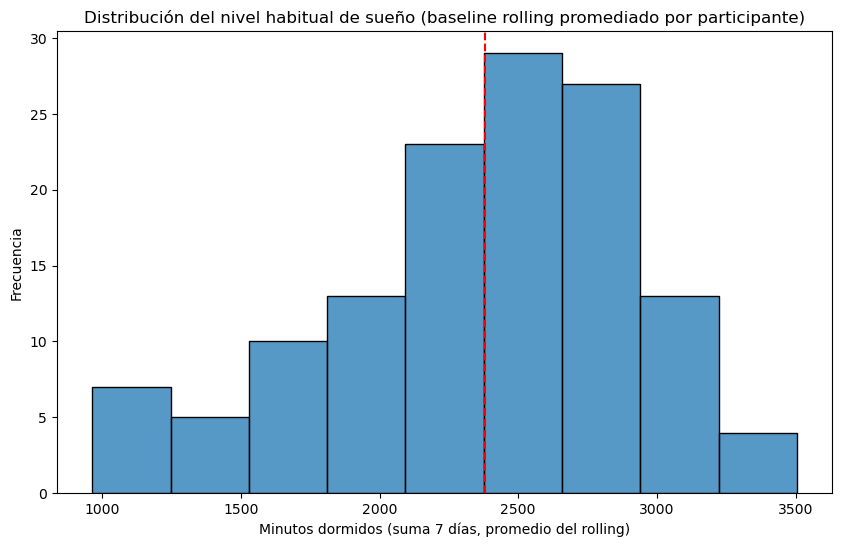

In [70]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep_resumen, x="mean")
plt.axvline(baseline_sleep_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de sueño (baseline rolling promediado por participante)")
plt.xlabel("Minutos dormidos (suma 7 días, promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución del nivel habitual de sueño es unimodal y aproximadamente simétrica, con la mayoría de participantes entre 1500 y 3500 minutos en ventana de 7 días (equivalente a 3.6-8.3 horas/noche). El pico se sitúa entre 2500 y 2750 minutos (aproximadamente 6-6.5 horas/noche) y la media del grupo (línea roja) ronda los 2400 minutos. Existe una cola izquierda con un grupo reducido de participantes en torno a 1000-1250 minutos (menos de 3 horas/noche), que ya señala heterogeneidad en el nivel habitual y justifica la lógica intra-sujeto: lo que para un participante son 6 horas habituales, para otro son 3 horas habituales, y ambos son su normalidad reciente.


**Distribución de la variabilidad individual**

Visualizamos la distribución del promedio de la desviación típica del baseline rolling de cada participante (columna `std` de `baseline_sleep_resumen`). Esto permite caracterizar cuán regulares o irregulares son los patrones de sueño entre participantes.


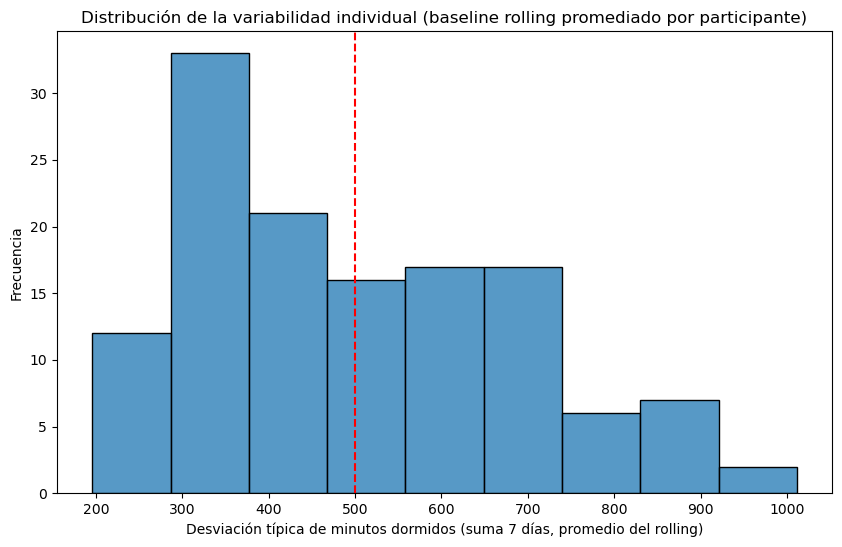

In [71]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep_resumen, x="std")
plt.axvline(baseline_sleep_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de minutos dormidos (suma 7 días, promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual está claramente sesgada a la derecha. La mayoría de participantes presenta std baja-moderada, con un pico marcado en torno a 300-400 minutos. La media del grupo (línea roja) se sitúa cerca de 500, arrastrada hacia arriba por una cola larga que llega hasta 1000 minutos. La asimetría refleja heterogeneidad real entre participantes: la mayoría tiene patrones de sueño relativamente regulares en su histórico reciente, y una minoría presenta std altas que el sistema debe interpretar como variabilidad propia, no como desviación. El z-score intra-sujeto del Bloque 3 normalizará la desviación de cada día por la std de la persona en sus 21 días previos, lo que ajusta automáticamente la sensibilidad a estas diferencias individuales.


**Relación entre nivel y variabilidad**

Visualizamos la relación entre las dos columnas de `baseline_sleep_resumen` mediante un scatter plot. Esto permite identificar si existe asociación entre el nivel habitual de sueño y la regularidad del patrón.


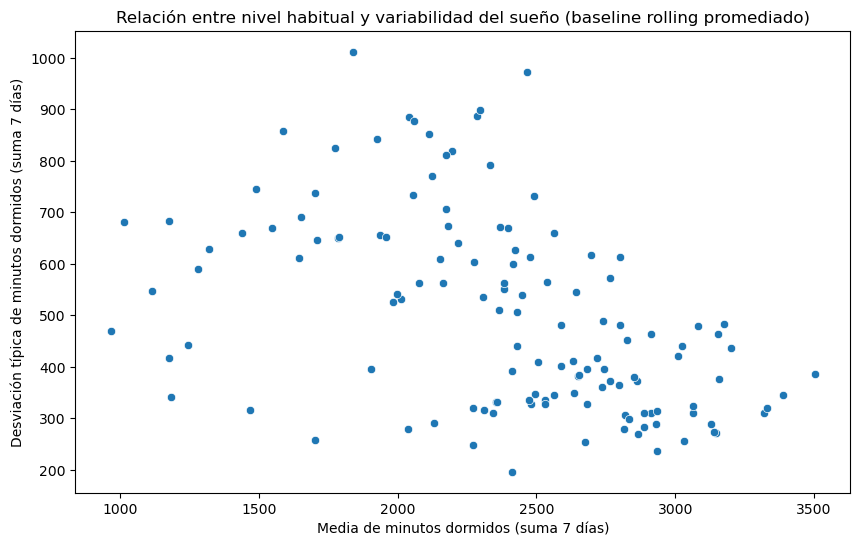

In [72]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_sleep_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad del sueño (baseline rolling promediado)")
plt.xlabel("Media de minutos dormidos (suma 7 días)")
plt.ylabel("Desviación típica de minutos dormidos (suma 7 días)")
plt.show()


El scatter muestra una correlación negativa visible entre el nivel habitual de sueño y la variabilidad individual: los participantes con `mean` alta (2500-3500 minutos) tienden a presentar `std` baja (200-500), mientras que los participantes con `mean` baja (menos de 2000 minutos) presentan `std` más dispersa y mayoritariamente alta (500-1000). Este patrón es consistente con la lectura conductual de que las personas con sueño habitualmente largo tienen rutinas más estables, mientras que sueño habitualmente corto suele coexistir con mayor irregularidad.

Esta asociación es informativa pero no condiciona el sistema: el z-score intra-sujeto se calcula contra la `mean` y `std` propias de cada participante en su histórico reciente. Las personas con std alta tendrán z-scores más conservadores; las personas con std baja, z-scores más sensibles. Esa es la lógica del enfoque intra-sujeto.


#### 1.5. Cierre del baseline rolling de sleep

Con esto queda construido el baseline rolling de sleep:

- Feature primaria: `f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 35, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual unimodal entre 1000 y 3500 minutos, distribución de variabilidad individual sesgada a la derecha y correlación negativa entre nivel y variabilidad.
- Algunos participantes quedan con baseline rolling no calculable (NaN en el resumen) por cobertura insuficiente. No son excluidos del proyecto: pueden volver a ser evaluables en días posteriores si su cobertura mejora.

Sobre esta referencia se calculará en el Bloque 3 el z-score intra-sujeto día a día. La misma lógica se aplica a continuación a steps, location y screen.


### `2. Steps`
#### 2.1. Identificación de la feature primaria


In [73]:
df_steps.columns[(df_steps.columns.str.contains("7dhist")) & ~(df_steps.columns.str.contains("norm")) & ~(df_steps.columns.str.contains("dis"))], df_steps.columns.shape


(Index(['f_steps:fitbit_steps_summary_rapids_maxsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_minsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_avgsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_mediansumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_stdsumsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_maxsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_minsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_avgsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_stdsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_countepisodesedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_sumdurationsedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_maxdurationsedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_mindurationsedentarybout:7dhist',
        'f_steps:fitbit_st

El dataset de steps contiene 597 columnas. Para encontrar la feature primaria, exploramos qué columnas tienen ventana 7dhist y versión raw. Seleccionamos `sumsteps` (suma intradiaria de pasos) como feature primaria por ser la medida más directa e interpretable de actividad física.


In [74]:
col_steps = 'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist'


#### 2.2. Preparación de la columna `day`


Aplicamos a `df_steps` el mismo procedimiento que se aplicó a `df_sleep`: calculamos para cada participante su fecha de inicio, convertimos las columnas de fecha a tipo datetime, y derivamos la columna `day` como diferencia entera de días desde el inicio de cada participante. Esta columna `day` es el eje temporal sobre el que opera el rolling posterior.


In [75]:
# creamos una serie con al fecha inicial de cada participante
start_date = df_steps.groupby("pid")["date"].min()
start_date.head()

pid
INS-W_001    2018-04-03
INS-W_002    2018-04-03
INS-W_003    2018-04-03
INS-W_004    2018-04-03
INS-W_005    2018-04-03
Name: date, dtype: object

In [76]:
start_date.dtype, df_steps["date"].dtype

(dtype('O'), dtype('O'))

`start_date` y `df_steps["date"]` están guardadas como strings. Las convertimos a su tipo nativo de fechas para poder operar con ellas.


In [77]:
df_steps["date"] = pd.to_datetime(df_steps["date"])
start_date = pd.to_datetime(start_date)
df_steps["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

``Materialización de start_date como columna:``
`start_date` es una Series de 155 elementos indexada por pid. Para que cada fila del DataFrame tenga acceso a la fecha de inicio de su participante, necesitamos una columna replicada al tamaño del DataFrame.

Asignamos a cada fila de `df_steps` la fecha de inicio de su participante creando la nueva columna `start_date`.


In [78]:
df_steps["start_date"] = df_steps["pid"].map(start_date)
df_steps["start_date"].head()


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
Name: start_date, dtype: datetime64[ns]

In [79]:
# comprobamos que le dataset tiene la nueva columna 'start_date'
df_steps.head(3)

,Unnamed: 0,pid,date,f_steps:fitbit_steps_summary_rapids_maxsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_minsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_avgsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_mediansumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_stdsumsteps:14dhist,f_steps:fitbit_steps_intraday_rapids_sumsteps:14dhist,f_steps:fitbit_steps_intraday_rapids_maxsteps:14dhist,...,f_steps:fitbit_steps_intraday_rapids_mindurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_avgdurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_stddurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_countepisodeactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_sumdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_maxdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_mindurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_avgdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_stddurationactivebout_norm:weekend,start_date
0,0,INS-W_001,2018-04-03,17287.0,17287.0,17287.0,17287.0,NaN,17287.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
1,1,INS-W_001,2018-04-04,17287.0,14958.0,16122.5,16122.5,1646.851693,32245.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
2,2,INS-W_001,2018-04-05,17287.0,14958.0,16245.0,16490.0,1183.671830,48735.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03


Calculamos el día relativo de cada fila como diferencia entre `date` y `start_date`. El resultado es un timedelta del que extraemos solo la parte entera de días.


In [80]:
df_steps["day"] = (df_steps["date"] - df_steps["start_date"]).dt.days
df_steps["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` contiene ahora el día relativo de cada fila, desde 0 hasta 91, en formato entero.


#### 2.3. Trabajo sobre el dataframe completo

Como en sleep, el baseline rolling necesita acceder a todos los días disponibles de cada participante. No se filtra `df_steps` a una ventana inicial. El criterio de cobertura del 70% se aplica internamente como `min_periods=15` dentro del rolling, y los participantes no se filtran a priori: cada día se evalúa de forma independiente.


#### 2.4. Cálculo del baseline rolling con buffer


Aplicamos a `col_steps` la misma operación rolling con buffer de 7 días que se aplicó a sleep. La justificación del buffer es la misma: la feature primaria es una suma deslizante de 7 días, y sin buffer la observación del día d compartiría datos crudos con los últimos valores del baseline, atenuando el z-score posterior.


In [81]:
baseline_steps = (
    df_steps.groupby("pid")[col_steps]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_steps.head(40)

mean           std
pid                                     
INS-W_001 0            NaN           NaN
          1            NaN           NaN
          2            NaN           NaN
          3            NaN           NaN
          4            NaN           NaN
          5            NaN           NaN
          6            NaN           NaN
          7            NaN           NaN
          8            NaN           NaN
          9            NaN           NaN
          10           NaN           NaN
          11           NaN           NaN
          12           NaN           NaN
          13           NaN           NaN
          14           NaN           NaN
          15           NaN           NaN
          16           NaN           NaN
          17           NaN           NaN
          18           NaN           NaN
          19           NaN           NaN
          20           NaN           NaN
          21  85509.333333  30469.335819
          22  86319.687500  29614.104391
          23  87286.352941  28949.412697
          24  88061.222222  28276.809437
          25  88402.473684  27520.347986
          26  88678.950000  26814.861195
          27  88575.095238  26140.226546
          28  91698.000000  20508.539775
          29  93945.904762  15686.330485
          30  95176.095238  12690.305492
          31  95804.047619  11293.078156
          32  95809.238095  11286.416291
          33  95098.523810  11804.939486
          34  93534.809524  11364.249534
          35  92835.380952  10885.048835
          36  92387.857143  10289.174657
          37  92599.000000  10587.447034
          38  92925.761905  10959.782101
          39  92959.095238  10983.205529

`baseline_steps` contiene, para cada participante y cada día del registro, su baseline rolling de steps en ese día concreto. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN`.


#### Visualización del baseline rolling de steps

Como en sleep, calculamos el promedio del baseline rolling por participante para inspeccionar visualmente la distribución entre participantes. Estas visualizaciones son exploratorias; la operativa real del sistema usa el baseline rolling completo.


In [82]:
baseline_steps_resumen = baseline_steps.groupby("pid").mean()
baseline_steps_resumen


,mean,std
pid,,
INS-W_001,82046.788339,17332.314329
INS-W_002,35445.410706,18459.262666
INS-W_003,49777.661163,18327.895083
INS-W_004,78858.297914,13327.863766
INS-W_005,88659.944390,13345.824672
...,...,...
INS-W_201,57741.695043,33090.784297
INS-W_202,43656.479361,19382.473565
INS-W_203,53348.119122,26618.922483


**Distribución del nivel habitual de steps**


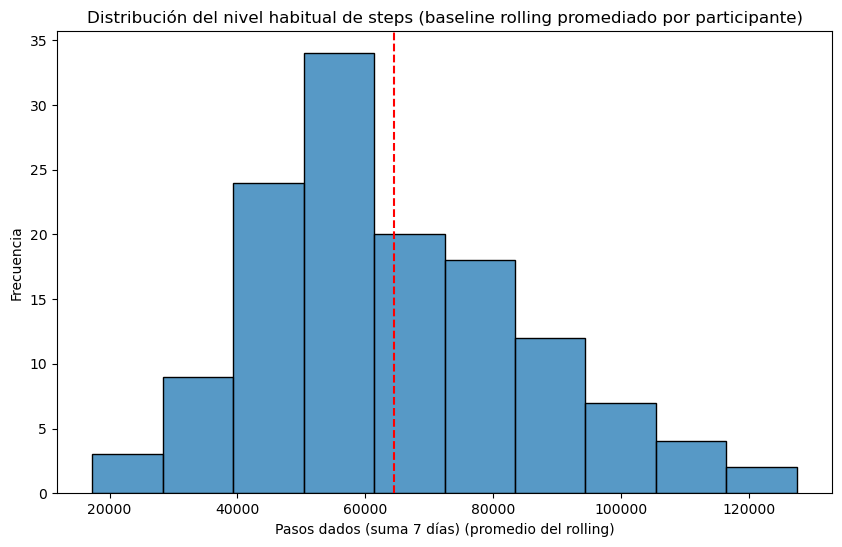

In [83]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_steps_resumen, x="mean")
plt.axvline(baseline_steps_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de steps (baseline rolling promediado por participante)")
plt.xlabel("Pasos dados (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución del nivel habitual de actividad es unimodal con asimetría a la derecha. La mayoría de participantes se sitúa entre 30000 y 90000 pasos en suma de 7 días (equivalente a 4300-12900 pasos/día), con un pico marcado entre 50000 y 60000 pasos (7100-8600 pasos/día). La media del grupo (línea roja) ronda los 65000 pasos, arrastrada hacia arriba por una cola derecha que llega hasta 120000-130000 (más de 17000 pasos/día). Existe también un grupo reducido en la zona baja (15000-25000 pasos en 7 días, menos de 3600 pasos/día).

La heterogeneidad observada es esperable: hay participantes con vida muy activa y participantes mayoritariamente sedentarios, y ambos extremos son normalidad propia de cada persona. El enfoque intra-sujeto evita comparar entre ellos: lo relevante no es si uno camina más que otro, sino si cada uno se aleja de su propio nivel habitual reciente.


**Distribución de la variabilidad individual**


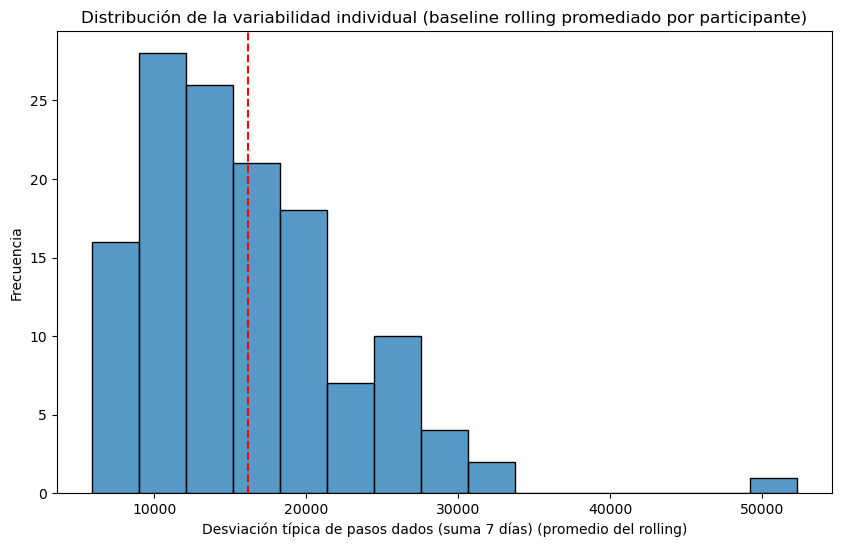

In [84]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_steps_resumen, x="std")
plt.axvline(baseline_steps_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de pasos dados (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual está claramente sesgada a la derecha. La mayoría de participantes se concentra en std de 8000-12000 pasos, con un pico marcado en esa zona. La media del grupo (línea roja) se sitúa cerca de 16000, arrastrada por una cola larga que llega hasta 30000, más algún caso aislado en torno a 50000.

La asimetría refleja que steps es una señal con mayor variabilidad estructural que sleep. La actividad física depende fuertemente del contexto diario (trabajo, tiempo libre, deporte ocasional, días festivos, clima), y un participante con std alta no es necesariamente irregular en sentido patológico, simplemente tiene una vida con mayor amplitud de actividad. El z-score intra-sujeto del Bloque 3 normaliza la desviación de cada día contra la std propia de la persona en sus 21 días previos, lo que ajusta automáticamente la sensibilidad al perfil de variabilidad de cada participante.


**Relación entre nivel y variabilidad**


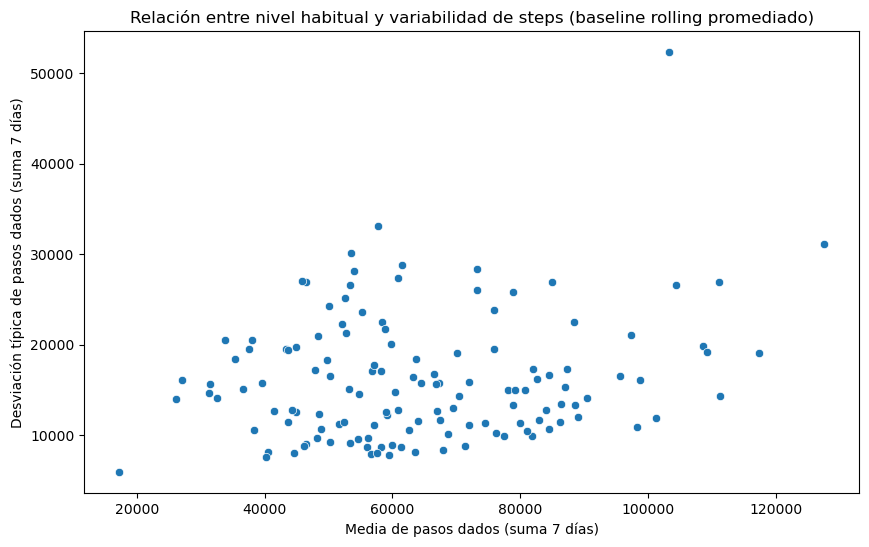

In [85]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_steps_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad de steps (baseline rolling promediado)")
plt.xlabel("Media de pasos dados (suma 7 días)")
plt.ylabel("Desviación típica de pasos dados (suma 7 días)")
plt.show()


El scatter no muestra correlación lineal clara entre el nivel habitual de actividad y la variabilidad individual. La nube de puntos se concentra en valores moderados de ambas dimensiones (mean entre 40000 y 90000 pasos en 7 días, std entre 8000 y 20000), sin un patrón sistemático que asocie nivel y variabilidad.

La ausencia de correlación contrasta con sleep, donde sí se observaba asociación negativa entre mean alta y std baja. En steps, participantes con nivel habitual similar pueden tener perfiles de variabilidad muy distintos, y participantes con std alta aparecen tanto en niveles bajos como altos de actividad. Esto refuerza la lógica intra-sujeto: la combinación nivel-variabilidad es propia de cada persona y no se deja resumir por una tendencia poblacional.


#### 2.5. Cierre del baseline rolling de steps

Con esto queda construido el baseline rolling de steps:

- Feature primaria: `f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 35, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual unimodal con asimetría derecha entre 15000 y 130000 pasos, distribución de variabilidad sesgada a la derecha y ausencia de correlación lineal entre nivel y variabilidad.
- Como en sleep, los participantes con baseline rolling no calculable por cobertura insuficiente no son excluidos: pueden volver a ser evaluables en días posteriores.


### `3. Location`
#### 3.1. Identificación de la feature primaria


In [86]:
df_location.columns[(df_location.columns.str.contains("7dhist")) & ~(df_location.columns.str.contains("norm")) & ~(df_location.columns.str.contains("dis"))], df_location.columns.shape


(Index(['f_loc:phone_locations_barnett_avgflightdur:7dhist',
        'f_loc:phone_locations_barnett_avgflightlen:7dhist',
        'f_loc:phone_locations_barnett_circdnrtn:7dhist',
        'f_loc:phone_locations_barnett_hometime:7dhist',
        'f_loc:phone_locations_barnett_maxdiam:7dhist',
        'f_loc:phone_locations_barnett_probpause:7dhist',
        'f_loc:phone_locations_barnett_rog:7dhist',
        'f_loc:phone_locations_barnett_siglocentropy:7dhist',
        'f_loc:phone_locations_barnett_siglocsvisited:7dhist',
        'f_loc:phone_locations_barnett_stdflightdur:7dhist',
        'f_loc:phone_locations_barnett_stdflightlen:7dhist',
        'f_loc:phone_locations_barnett_wkenddayrtn:7dhist',
        'f_loc:phone_locations_doryab_avglengthstayatclusters:7dhist',
        'f_loc:phone_locations_doryab_avgspeed:7dhist',
        'f_loc:phone_locations_doryab_homelabel:7dhist',
        'f_loc:phone_locations_doryab_locationentropy:7dhist',
        'f_loc:phone_locations_doryab_locat

El dataset de location contiene 1110 columnas. Para encontrar la feature primaria, filtramos las que tienen ventana 7dhist y versión raw. Seleccionamos `rog` (radius of gyration, radio de giro) como feature primaria. Mide la dispersión espacial del usuario alrededor de su centro de masas geográfico, sintetizando en un único valor lo amplio o restringido que es su espacio vital.


In [87]:
col_location = 'f_loc:phone_locations_barnett_rog:7dhist'


#### 3.2. Preparación de la columna `day`


Aplicamos a `df_location` el mismo procedimiento que se aplicó a `df_sleep`: calculamos para cada participante su fecha de inicio, convertimos las columnas de fecha a tipo datetime, y derivamos la columna `day` como diferencia entera de días desde el inicio de cada participante. Esta columna `day` es el eje temporal sobre el que opera el rolling posterior.


In [88]:
start_date = df_location.groupby("pid")["date"].min()
start_date.dtype, df_location["date"].dtype


(dtype('O'), dtype('O'))

`start_date` y `df_location["date"]` están guardadas como strings. Las convertimos a su tipo nativo de fechas para poder operar con ellas.


In [89]:
df_location["date"] = pd.to_datetime(df_location["date"])
start_date = pd.to_datetime(start_date)
df_location["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

Asignamos a cada fila de `df_location` la fecha de inicio de su participante creando una nueva columna `start_date`.


In [90]:
df_location["start_date"] = df_location["pid"].map(start_date)
df_location["start_date"].head(10)


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Calculamos el día relativo de cada fila como diferencia entre `date` y `start_date`. El resultado es un timedelta del que extraemos solo la parte entera de días.


In [91]:
df_location["day"] = (df_location["date"] - df_location["start_date"]).dt.days
df_location["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` contiene ahora el día relativo de cada fila, desde 0 hasta 91, en formato entero.


#### 3.3. Trabajo sobre el dataframe completo

Como en sleep, el baseline rolling necesita acceder a todos los días disponibles de cada participante. No se filtra `df_location` a una ventana inicial. El criterio de cobertura del 70% se aplica internamente como `min_periods=15` dentro del rolling, y los participantes no se filtran a priori: cada día se evalúa de forma independiente.


#### 3.4. Cálculo del baseline rolling con buffer


Aplicamos a `col_location` la misma operación rolling con buffer de 7 días que se aplicó a sleep. La justificación del buffer es la misma: la feature primaria es una suma deslizante de 7 días, y sin buffer la observación del día d compartiría datos crudos con los últimos valores del baseline, atenuando el z-score posterior.


In [92]:
baseline_location = (
    df_location
    .groupby("pid")[col_location]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_location.head(40)


mean         std
pid                                  
INS-W_001 0           NaN         NaN
          1           NaN         NaN
          2           NaN         NaN
          3           NaN         NaN
          4           NaN         NaN
          5           NaN         NaN
          6           NaN         NaN
          7           NaN         NaN
          8           NaN         NaN
          9           NaN         NaN
          10          NaN         NaN
          11          NaN         NaN
          12          NaN         NaN
          13          NaN         NaN
          14          NaN         NaN
          15          NaN         NaN
          16          NaN         NaN
          17          NaN         NaN
          18          NaN         NaN
          19          NaN         NaN
          20          NaN         NaN
          21          NaN         NaN
          22          NaN         NaN
          23          NaN         NaN
          24          NaN         NaN
          25          NaN         NaN
          26          NaN         NaN
          27          NaN         NaN
          28          NaN         NaN
          29          NaN         NaN
          30          NaN         NaN
          31          NaN         NaN
          32          NaN         NaN
          33          NaN         NaN
          34          NaN         NaN
          35  1924.725008  608.033849
          36  1884.295420  609.270857
          37  1843.809146  613.086979
          38  1780.518287  652.586011
          39  1710.060899  704.648684

`baseline_location` contiene, para cada participante y cada día del registro, su baseline rolling de location en ese día concreto. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN`.


#### Visualización del baseline rolling de location

Como en sleep, calculamos el promedio del baseline rolling por participante para inspeccionar visualmente la distribución entre participantes. Estas visualizaciones son exploratorias; la operativa real del sistema usa el baseline rolling completo.


In [93]:
baseline_location_resumen = baseline_location.groupby("pid").mean()
baseline_location_resumen

,mean,std
pid,,
INS-W_001,1718.554503,570.365056
INS-W_002,15645.721685,12986.531116
INS-W_003,2560.895561,3391.020521
INS-W_004,2757.124446,1844.212420
INS-W_005,2663.982545,1844.719456
...,...,...
INS-W_201,2340.299649,880.308045
INS-W_202,25651.273832,33119.285850
INS-W_203,5096.378240,2826.953596


**Distribución del nivel habitual de location**


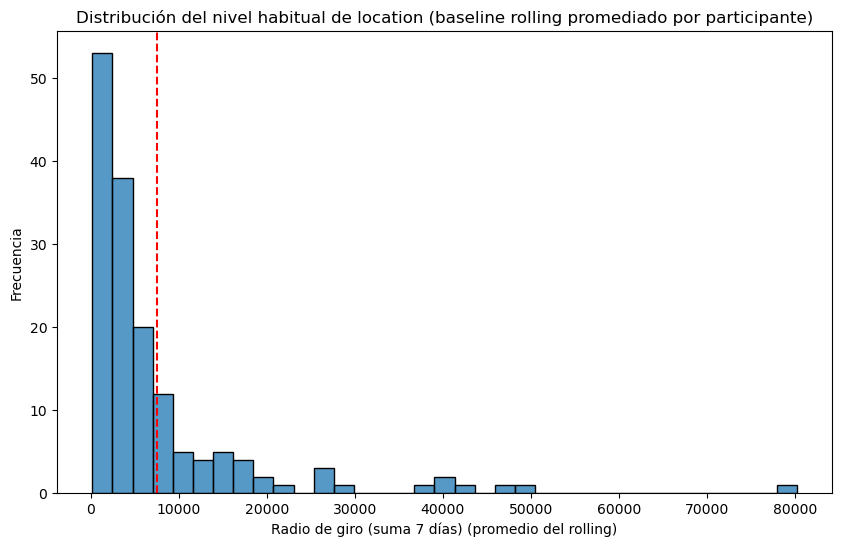

In [94]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_location_resumen, x="mean")
plt.axvline(baseline_location_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de location (baseline rolling promediado por participante)")
plt.xlabel("Radio de giro (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución del nivel habitual de movilidad espacial presenta asimetría a la derecha extrema. La mayoría de participantes se concentra en valores bajos: el pico más alto está en 0-2500 metros (más de 50 participantes), seguido de un escalón rápido que decae hacia los 10000-15000. La media del grupo (línea roja) ronda los 8000 metros, arrastrada hacia arriba por una cola muy larga con valores dispersos hasta 80000.

Esta forma de distribución refleja heterogeneidad estructural en estilos de vida: la mayoría de participantes opera en un radio espacial reducido (zona doméstica, trabajo o estudio cercanos), y una minoría tiene patrones de movilidad mucho más amplios (desplazamientos largos, varios contextos geográficos en la semana). Con baseline rolling, esta heterogeneidad no se trata como un problema, sino como información: cada participante se compara consigo mismo, y un radio bajo es la normalidad de unos y un radio alto la normalidad de otros.


**Distribución de la variabilidad individual**


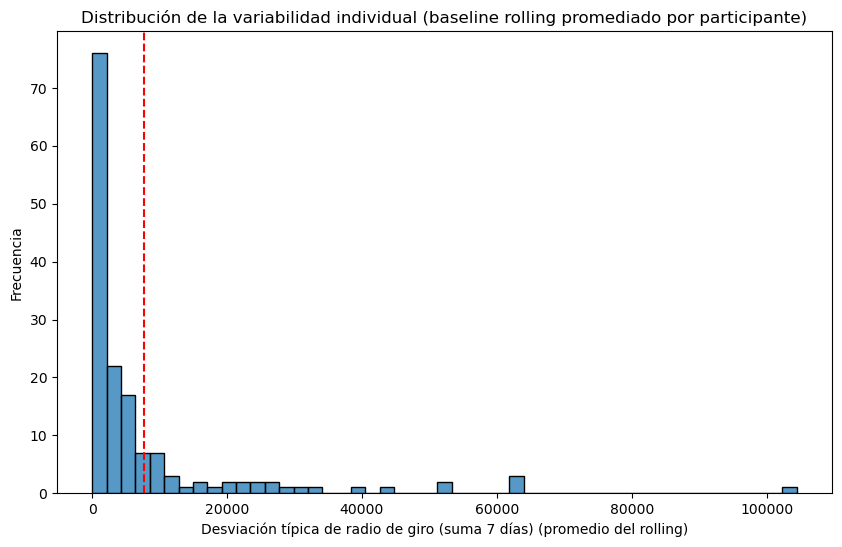

In [95]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_location_resumen, x="std")
plt.axvline(baseline_location_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de radio de giro (suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual está aún más sesgada a la derecha que la del nivel habitual. El pico es enorme en 0-5000 (cerca de 75 participantes concentrados ahí). La media del grupo (línea roja) se sitúa cerca de 9000, y la cola se extiende hasta más de 100000 con casos aislados.

La interpretación es coherente con el plot anterior: la mayoría de participantes tiene un patrón espacial muy estable semana a semana (rutinas geográficas similares), y una minoría con movilidad amplia presenta también mayor variabilidad espacial. Como en steps, una std alta no se interpreta automáticamente como irregularidad patológica, sino como amplitud de patrón propia. El z-score intra-sujeto del Bloque 3 normaliza contra la std propia de cada persona, lo que ajusta la sensibilidad a estos perfiles tan distintos.


**Relación entre nivel y variabilidad**


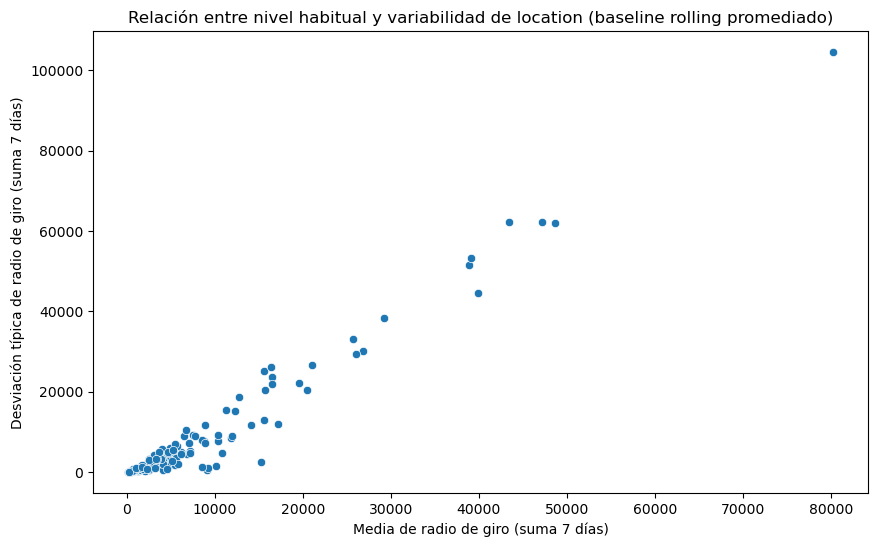

In [96]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_location_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad de location (baseline rolling promediado)")
plt.xlabel("Media de radio de giro (suma 7 días)")
plt.ylabel("Desviación típica de radio de giro (suma 7 días)")
plt.show()


El scatter muestra una correlación lineal positiva muy clara entre el nivel habitual de movilidad y la variabilidad individual. La nube de puntos se alinea sobre un eje diagonal limpio: participantes con `mean` baja (0-10000) tienen `std` baja (0-5000), y a medida que aumenta `mean`, aumenta `std` proporcionalmente, hasta los participantes con mayor radio de giro (más de 50000) que presentan también la mayor variabilidad espacial (más de 50000).

Esta asociación es muy distinta a las observadas en sleep (correlación negativa) y steps (sin correlación clara). En location, la asociación positiva es esperable: una persona con un patrón espacial amplio tiene más oportunidades de variar geográficamente semana a semana, y el radio de giro está acotado por debajo en personas con vida más doméstica. La asociación es informativa pero no condiciona el sistema: el z-score intra-sujeto se calcula contra la `mean` y `std` propias de cada participante en su histórico reciente, así que la sensibilidad se ajusta automáticamente al perfil espacial de cada persona.


#### 3.5. Cierre del baseline rolling de location

Con esto queda construido el baseline rolling de location:

- Feature primaria: `f_loc:phone_locations_barnett_rog:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 35, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual con asimetría derecha extrema (concentración en 0-15000 metros y cola hasta 80000), distribución de variabilidad muy sesgada a la derecha y correlación lineal positiva clara entre nivel y variabilidad.
- Como en sleep y steps, los participantes con baseline rolling no calculable por cobertura insuficiente no son excluidos: pueden volver a ser evaluables en días posteriores.


### `4. Screen`
#### 4.1. Identificación de la feature primaria


In [97]:
df_screen.columns[(df_screen.columns.str.contains("7dhist")) & ~(df_screen.columns.str.contains("norm")) & ~(df_screen.columns.str.contains("dis"))], df_screen.columns.shape

(Index(['f_screen:phone_screen_rapids_countepisodeunlock:7dhist',
        'f_screen:phone_screen_rapids_sumdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_maxdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_mindurationunlock:7dhist',
        'f_screen:phone_screen_rapids_avgdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_stddurationunlock:7dhist',
        'f_screen:phone_screen_rapids_firstuseafter00unlock:7dhist',
        'f_screen:phone_screen_rapids_countepisodeunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_sumdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_maxdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_mindurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_avgdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_stddurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_firstuseafter00

El dataset de screen contiene 1137 columnas. Para encontrar la feature primaria, filtramos las que tienen ventana 7dhist y versión raw. Seleccionamos `sumdurationunlock` (suma de duración de uso desbloqueado) como feature primaria por ser la medida más directa de tiempo total de interacción con el dispositivo.


In [98]:
col_screen = 'f_screen:phone_screen_rapids_sumdurationunlock:7dhist'


#### 4.2. Preparación de la columna `day`


Aplicamos a `df_screen` el mismo procedimiento que se aplicó a `df_sleep`: calculamos para cada participante su fecha de inicio, convertimos las columnas de fecha a tipo datetime, y derivamos la columna `day` como diferencia entera de días desde el inicio de cada participante. Esta columna `day` es el eje temporal sobre el que opera el rolling posterior.


In [99]:
start_date = df_screen.groupby("pid")["date"].min()
start_date.dtype, df_screen["date"].dtype


(dtype('O'), dtype('O'))

`start_date` y `df_screen["date"]` están guardadas como strings. Las convertimos a su tipo nativo de fechas para poder operar con ellas.


In [100]:
df_screen["date"] = pd.to_datetime(df_screen["date"])
start_date = pd.to_datetime(start_date)
df_screen["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

Asignamos a cada fila de `df_screen` la fecha de inicio de su participante creando una nueva columna `start_date`.


In [101]:
df_screen["start_date"] = df_screen["pid"].map(start_date)
df_screen["start_date"].head(10)


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Calculamos el día relativo de cada fila como diferencia entre `date` y `start_date`. El resultado es un timedelta del que extraemos solo la parte entera de días.


In [102]:
df_screen["day"] = (df_screen["date"] - df_screen["start_date"]).dt.days
df_screen["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

La columna `day` contiene ahora el día relativo de cada fila, desde 0 hasta 91, en formato entero.


#### 4.3. Trabajo sobre el dataframe completo

Como en sleep, el baseline rolling necesita acceder a todos los días disponibles de cada participante. No se filtra `df_screen` a una ventana inicial. El criterio de cobertura del 70% se aplica internamente como `min_periods=15` dentro del rolling, y los participantes no se filtran a priori: cada día se evalúa de forma independiente.


#### 4.4. Cálculo del baseline rolling con buffer


Aplicamos a `col_screen` la misma operación rolling con buffer de 7 días que se aplicó a sleep. La justificación del buffer es la misma: la feature primaria es una suma deslizante de 7 días, y sin buffer la observación del día d compartiría datos crudos con los últimos valores del baseline, atenuando el z-score posterior.


In [110]:
baseline_screen = (
    df_screen
    .groupby("pid")[col_screen]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_screen.head(80)

mean         std
pid                                 
INS-W_001 0          NaN         NaN
          1          NaN         NaN
          2          NaN         NaN
          3          NaN         NaN
          4          NaN         NaN
...                  ...         ...
          75  347.207426  175.509386
          76  340.592052  177.362305
          77  333.280322  179.098828
          78  325.156178  180.652809
          79  321.493326  185.522403

[80 rows x 2 columns]

`baseline_screen` contiene, para cada participante y cada día del registro, su baseline rolling de screen en ese día concreto. Los días con cobertura insuficiente o demasiado al inicio del registro quedan como `NaN`.


#### Visualización del baseline rolling de screen

Como en sleep, calculamos el promedio del baseline rolling por participante para inspeccionar visualmente la distribución entre participantes. Estas visualizaciones son exploratorias; la operativa real del sistema usa el baseline rolling completo.


In [104]:
baseline_screen_resumen = baseline_screen.groupby("pid").mean()
baseline_screen_resumen

,mean,std
pid,,
INS-W_001,960.844599,377.668884
INS-W_002,1320.822537,329.233739
INS-W_003,3358.886725,419.270303
INS-W_004,1784.326836,382.952496
INS-W_005,2544.433617,437.955674
...,...,...
INS-W_201,2310.091396,353.543745
INS-W_202,1862.160035,482.678725
INS-W_203,1831.604275,185.223710


**Distribución del nivel habitual de screen**


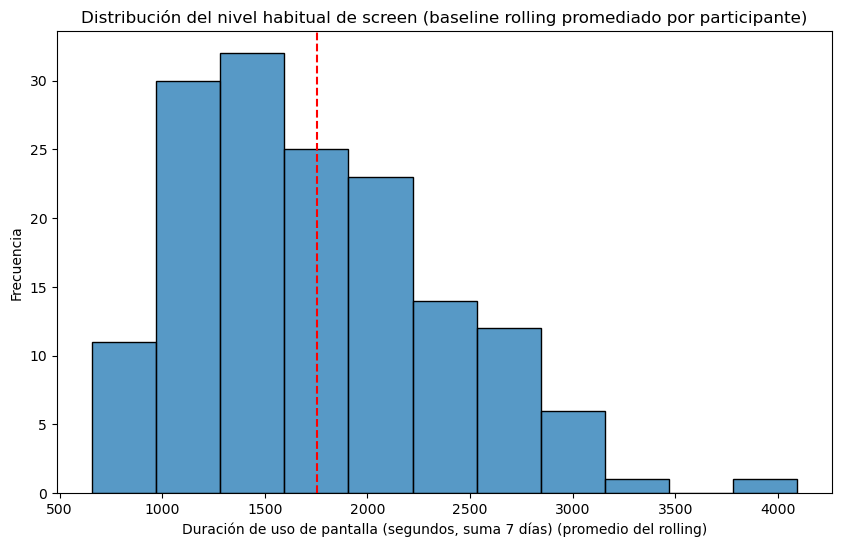

In [105]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_screen_resumen, x="mean")
plt.axvline(baseline_screen_resumen["mean"].mean(), color="red", linestyle="--")
plt.title("Distribución del nivel habitual de screen (baseline rolling promediado por participante)")
plt.xlabel("Duración de uso de pantalla (segundos, suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()

La distribución del nivel habitual de uso de pantalla presenta asimetría a la derecha. La mayoría de participantes se concentra entre 1000 y 2500 segundos en suma de 7 días, con un pico marcado en 1000-1500 (más de 30 participantes) y una segunda zona alta en 1500-2000 con altura similar. La media del grupo (línea roja) ronda los 1750 segundos. La cola decae progresivamente y se extiende hasta 3500-4000 segundos con casos aislados.

Esta forma intermedia (asimétrica pero sin la concentración extrema de location) es coherente con que el uso de pantalla está más uniformemente distribuido entre la cohorte que la movilidad espacial. Hay diferencias notables en uso habitual entre participantes, pero todos hacen algún uso del dispositivo, lo que reduce la cola izquierda. Como en las dimensiones anteriores, el sistema no compara entre participantes, sino que toma el nivel habitual reciente de cada uno como referencia propia.


**Distribución de la variabilidad individual**


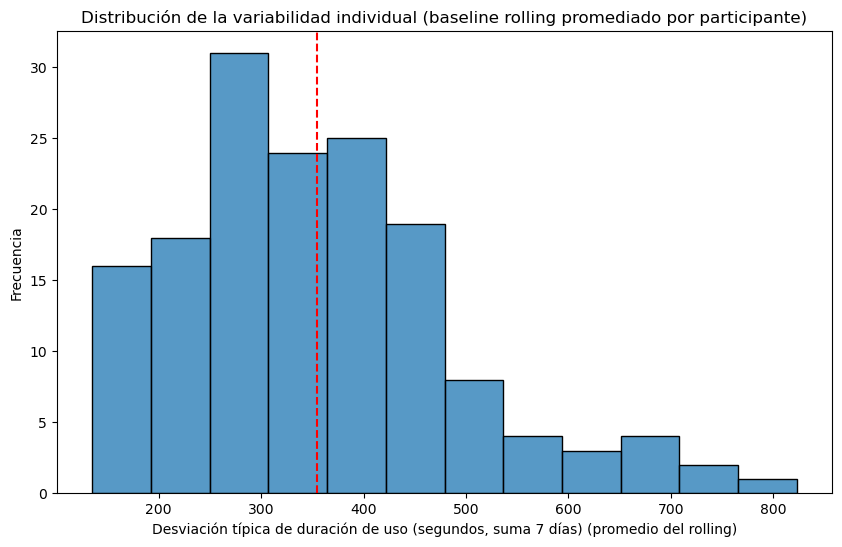

In [106]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_screen_resumen, x="std")
plt.axvline(baseline_screen_resumen["std"].mean(), color="red", linestyle="--")
plt.title("Distribución de la variabilidad individual (baseline rolling promediado por participante)")
plt.xlabel("Desviación típica de duración de uso (segundos, suma 7 días) (promedio del rolling)")
plt.ylabel("Frecuencia")
plt.show()


La distribución de la variabilidad individual presenta asimetría a la derecha clara. El pico se sitúa en 250-300 segundos, con la mayoría de participantes concentrados entre 150 y 500. La media del grupo (línea roja) ronda los 350 segundos, y la cola se extiende hasta 800 con frecuencia decreciente.

La interpretación es coherente con que el uso de pantalla, aunque variable, lo es de forma menos extrema que steps o location. La mayoría de participantes mantiene un patrón de uso relativamente regular semana a semana, con una minoría más variable. El z-score intra-sujeto del Bloque 3 normaliza contra la std propia de cada persona, lo que ajusta automáticamente la sensibilidad al perfil de regularidad de cada participante.


**Relación entre nivel y variabilidad**


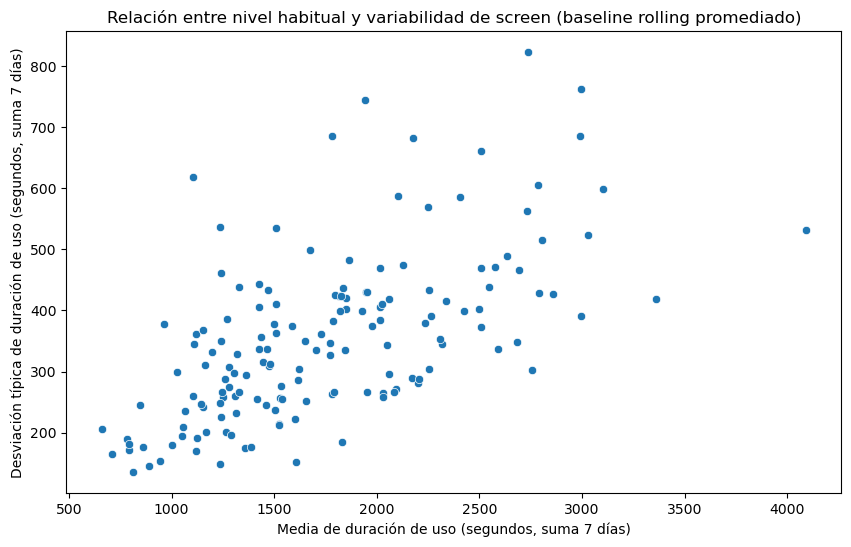

In [107]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_screen_resumen, x="mean", y="std")
plt.title("Relación entre nivel habitual y variabilidad de screen (baseline rolling promediado)")
plt.xlabel("Media de duración de uso (segundos, suma 7 días)")
plt.ylabel("Desviación típica de duración de uso (segundos, suma 7 días)")
plt.show()


El scatter muestra correlación positiva moderada entre el nivel habitual de uso y la variabilidad individual. La tendencia es visible (mean alta tiende a std alta) pero con dispersión amplia: para un mismo nivel medio de uso, los participantes presentan std muy distintas. El patrón es más limpio que en sleep o steps, pero menos marcado que en location.

Esta posición intermedia tiene una lectura conductual razonable: un participante que usa más el móvil en términos absolutos tiene también más oportunidades de variar semana a semana, pero el techo de variabilidad está más acotado que en movilidad espacial. La asociación es informativa pero no condiciona el sistema, porque el z-score intra-sujeto se calcula contra la `mean` y `std` propias de cada participante.


#### 4.5. Cierre del baseline rolling de screen

Con esto queda construido el baseline rolling de screen:

- Feature primaria: `f_screen:phone_screen_rapids_sumdurationunlock:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 35, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual con asimetría derecha entre 500 y 4000 segundos, distribución de variabilidad sesgada a la derecha y correlación positiva moderada entre nivel y variabilidad.
- Como en sleep, steps y location, los participantes con baseline rolling no calculable por cobertura insuficiente no son excluidos: pueden volver a ser evaluables en días posteriores.

### **Cierre del Bloque 2**

Con sleep, steps, location y screen, el Bloque 2 queda completado. El sistema dispone ahora de cuatro baselines rolling individuales, uno por dimensión, calculados sobre los 21 días que terminan 7 días antes de cada día de evaluación. Cada baseline contiene, para cada par persona-día, la media y la desviación típica que servirán de referencia individual en el cálculo del z-score intra-sujeto del Bloque 3.

Los participantes con baseline no calculable en una dimensión un día concreto se omiten de esa dimensión ese día, sin ser excluidos del proyecto. La regla de convergencia 2/3 entre dimensiones se aplicará en el Bloque 3 sobre los días en que el participante tenga al menos dos dimensiones evaluables.


## Bloque 3: Z-score intra-sujeto

### 3.1. Qué calcula este bloque y por qué es la segunda pieza técnica del sistema

El Bloque 2 produjo cuatro baselines, uno por dimensión, que contienen para cada par persona-día la media y la desviación típica del comportamiento habitual reciente de esa persona. El Bloque 3 usa esos baselines para responder a una pregunta concreta: para cada día evaluable, **¿cuánto se aleja la observación de hoy del patrón habitual reciente de esta persona?**

La medida es el z-score intra-sujeto: `z = (observación − mean) / std`. Es la fórmula convencional del z-score, pero su semántica aquí es la del marco N-of-1. La media y la desviación típica no provienen de la población; provienen del propio historial reciente de la persona. El resultado no compara a la persona con un grupo de referencia, la compara consigo misma a lo largo del tiempo.

El output del bloque son cuatro `Series`, una por dimensión (`z_sleep`, `z_steps`, `z_location`, `z_screen`), indexadas por `(pid, idx)` igual que los baselines. Cada Series tiene valor numérico en los pares persona-día evaluables y `NaN` en los no evaluables. Los pares con NaN en mean o std (por baseline no calculable) quedan automáticamente excluidos por aritmética: cualquier operación con NaN produce NaN. No se aplica imputación.

La decisión de mantener el z-score como Series separada por dimensión, y no como columna añadida al DataFrame de cada dimensión, responde a tres razones: el z-score no es una propiedad de la observación cruda sino una relación con un baseline concreto; su dominio natural son los pares evaluables, no todos los pares; y los bloques posteriores operan sobre las cuatro dimensiones simultáneamente, lo que se resuelve trivialmente con cuatro Series del mismo índice.

#### 3.2. Construcción del z-score para sleep

Aplicamos la fórmula del z-score sobre la dimensión sleep como dimensión piloto. La operación combina dos objetos ya construidos: la columna `col_sleep` de `df_sleep`, que contiene la observación cruda 7dhist de cada par persona-día, y el DataFrame `baseline_sleep`, que contiene la media y la desviación típica del baseline rolling de esa misma persona para ese mismo día.

z_sleep = (df_sleep[col_sleep] - baseline_sleep["mean"]) / baseline_sleep["std"]

In [ ]:
df_sleep[col_sleep]

0      347.0
1      742.0
2     1313.0
3     1667.0
4     2264.0
5     2709.0
6     3326.0
7     3389.0
8     3503.0
9     3526.0
10    3513.0
11    3451.0
12    3375.0
13    2758.0
14    2744.0
15    2737.0
16    2592.0
17    2791.0
18    2694.0
19    2325.0
20    2761.0
21    2980.0
22    2864.0
23    2778.0
24    2613.0
25    2175.0
26    2673.0
27    2853.0
28    2771.0
29    2812.0
30    3147.0
31    3221.0
32    3610.0
33    3403.0
34    3270.0
35    3106.0
36    3184.0
37    2974.0
38    2840.0
39    3127.0
Name: f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist, dtype: float64